<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/Groupe7_AIR_FISA_KDD_Attaques_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Détection d'intrusions NSL-KDD

Dans ce notebook, nous rassemblons l'ensemble du projet : l'exploration complète des données et leur prétraitement, puis tous les graphiques de modélisation. On entraîne sur `KDDTrain+` et on teste sur le `KDDTest+` séparé, jamais vu.

Pour reproduire nos résultats, chargez `KDDTrain+.txt` (complet) **ou** `KDDTrain__20Percent.txt`, ainsi que `KDDTest_.txt`. Notre exploration utilise le fichier d'entraînement ; tous les scores de modèles ci-dessous sont en Entraînement→Test.

## 0. Bibliothèques et fonctions utilitaires

In [3]:
import pandas as pd, numpy as np, math, warnings, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, mean_squared_error,
                             classification_report, ConfusionMatrixDisplay)
pd.set_option('display.max_columns', 60); plt.rcParams['figure.figsize']=(8,4); plt.rcParams['figure.dpi']=90

# --- helpers reproduced from the course / 02 notebook ---
def rotate_labels(sm, x_rot=90, y_rot=0):
    for ax in sm.ravel():
        ax.set_xlabel(ax.get_xlabel(), rotation=x_rot)
        ax.set_ylabel(ax.get_ylabel(), rotation=y_rot, ha='right', va='center')
def plot_corr(frame, width=10, height=10, print_value=False):
    corr=frame.corr(numeric_only=True)
    fig,ax=plt.subplots(figsize=(width,height))
    im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns,rotation=90,fontsize=7)
    ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns,fontsize=7)
    fig.colorbar(im,shrink=0.7); plt.tight_layout(); plt.show()
def get_features_correlated_to_target(frame, target_feature):
    corr=frame.corr(numeric_only=True)[target_feature].drop(target_feature)
    return corr.abs().sort_values(ascending=False)

## 1. Chargement des données (jeu complet de préférence)

In [4]:
COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']
attack_category = {
    'neptune':'DoS','smurf':'DoS','back':'DoS','teardrop':'DoS','pod':'DoS','land':'DoS',
    'apache2':'DoS','processtable':'DoS','mailbomb':'DoS','udpstorm':'DoS','worm':'DoS',
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L','warezmaster':'R2L',
    'warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L','snmpguess':'R2L','snmpgetattack':'R2L',
    'httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R','sqlattack':'U2R',
    'xterm':'U2R','ps':'U2R'}
def _resolve_train():
    fs=[f for f in sorted(os.listdir('.')) if f.lower().endswith(('.txt','.csv'))]
    full=[f for f in fs if 'train' in f.lower() and '20' not in f.lower() and 'percent' not in f.lower()]
    if full: print('Using FULL training set:', full[0]); return full[0]
    sub=[f for f in fs if 'train' in f.lower()]
    if sub:
        print('NOTE: full KDDTrain+.txt not found -> using the 20% subset:', sub[0])
        print('      Upload KDDTrain+.txt (the ~126k-row file) to use the FULL dataset.')
        return sub[0]
    from google.colab import files as gf; up=gf.upload()
    for f in up:
        if 'train' in f.lower(): return f
    return list(up.keys())[0]
def _resolve_test():
    fs=[f for f in sorted(os.listdir('.')) if f.lower().endswith(('.txt','.csv'))]
    t=[f for f in fs if 'test' in f.lower()]
    if t: return t[0]
    from google.colab import files as gf; up=gf.upload()
    for f in up:
        if 'test' in f.lower(): return f
    return list(up.keys())[0]
def load(path):
    has_header=open(path).readline().lower().startswith('duration')
    d=pd.read_csv(path, header=0 if has_header else None); d.columns=COL_NAMES
    d['is_attack']=(d['attack']!='normal').astype(int)
    d['category']=d['attack'].apply(lambda a:'normal' if a=='normal' else attack_category.get(a,'unknown'))
    for c in ['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count']:
        d[c+'_log']=np.log1p(d[c])
    return d
df=load(_resolve_train())
df_test_official=load(_resolve_test())
BASE=['same_srv_rate','src_bytes_log','dst_bytes_log','dst_host_srv_count','logged_in',
      'serror_rate','diff_srv_rate','count_log','dst_host_same_srv_rate','srv_count_log']
CONTENT=['hot','num_failed_logins','num_compromised','root_shell','su_attempted',
         'num_root','num_file_creations','num_shells','num_access_files','is_guest_login']
FEATURES=BASE+CONTENT
# ===== PROPER NSL-KDD PROTOCOL =====
# TRAIN on the training file, TEST on the SEPARATE official test file.
dtr, dte = df, df_test_official                       # dtr = train file, dte = test file
ytr, yte = df['is_attack'].values, df_test_official['is_attack'].values
dtr_c, dte_c = df, df_test_official
ytr_c, yte_c = df['category'].values, df_test_official['category'].values
# a sample for the heavy visual plots (keeps them fast & readable on the full 126k set)
df_viz=df.sample(min(25000,len(df)), random_state=0)
print('\nloaded training rows:', len(df), '| official test rows:', len(df_test_official))

NOTE: full KDDTrain+.txt not found -> using the 20% subset: KDDTrain+_20Percent.txt
      Upload KDDTrain+.txt (the ~126k-row file) to use the FULL dataset.

loaded training rows: 25192 | official test rows: 22544


# Partie 1 — Exploration des données

Avant de modéliser quoi que ce soit, nous avons voulu *regarder* les données correctement : leur forme, l'équilibre des classes, l'asymétrie, quelles variables séparent réellement les attaques du trafic normal, la structure de corrélation, et — la partie qui nous a le plus surpris — l'effet de la transformation log. Chaque décision de prétraitement que nous prenons plus loin dans le notebook est justifiée par quelque chose que l'on découvre d'abord dans cette section.

### 1.1 Premier regard — structure et colonnes

In [5]:
display(df.head(8))
df.info(verbose=False)
print('\nattack types:', df['attack'].unique()[:12], '...')
print('protocols   :', df['protocol_type'].unique())
print('flags       :', df['flag'].unique())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,is_attack,category,duration_log,src_bytes_log,dst_bytes_log,count_log,srv_count_log,dst_host_count_log,dst_host_srv_count_log
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0,normal,0.0,6.198479,0.000000,1.098612,1.098612,5.017280,3.258097
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0,normal,0.0,4.990433,0.000000,2.639057,0.693147,5.545177,0.693147
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1,DoS,0.0,0.000000,0.000000,4.820282,1.945910,5.545177,3.295837
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0,normal,0.0,5.451038,9.006264,1.791759,1.791759,3.433987,5.545177
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0,normal,0.0,5.298317,6.042633,3.433987,3.496508,5.545177,5.545177
5,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,1,DoS,0.0,0.000000,0.000000,4.804021,2.995732,5.545177,2.995732
6,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,166,9,1.0,1.0,0.0,0.0,0.05,0.06,0.00,255,9,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21,1,DoS,0.0,0.000000,0.000000,5.117994,2.302585,5.545177,2.302585
7,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,117,16,1.0,1.0,0.0,0.0,0.14,0.06,0.00,255,15,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21,1,DoS,0.0,0.000000,0.000000,4.770685,2.833213,5.545177,2.772589


<class 'pandas.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Columns: 52 entries, duration to dst_host_srv_count_log
dtypes: float64(22), int64(25), str(5)
memory usage: 10.0 MB

attack types: <StringArray>
[      'normal',      'neptune',  'warezclient',      'ipsweep',
    'portsweep',     'teardrop',         'nmap',        'satan',
        'smurf',          'pod',         'back', 'guess_passwd']
Length: 12, dtype: str ...
protocols   : <StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str
flags       : <StringArray>
['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2', 'OTH']
Length: 11, dtype: str


**Ce que l'on voit ici :** chaque ligne est une seule connexion. On peut regrouper les colonnes en trois familles — les informations TCP de base (`duration`, `protocol_type`, `service`, `flag`, les comptes d'octets), les variables de contenu (`hot`, `logged_in`, `root_shell`…), et les statistiques de trafic sur fenêtre temporelle (`count`, `serror_rate`, `same_srv_rate`…). Nous avons aussi vérifié et confirmé qu'il n'y a aucune valeur manquante dans NSL-KDD, ce qui rend notre travail de nettoyage bien plus simple — nous n'aurons besoin d'aucune étape d'imputation.

### 1.2 Les étiquettes et leur équilibre — la difficulté centrale

Binary balance (%):
is_attack
0    53.4
1    46.6
Name: proportion, dtype: float64

By category:
category
normal    13449
DoS        9234
Probe      2289
R2L         209
U2R          11
Name: count, dtype: int64


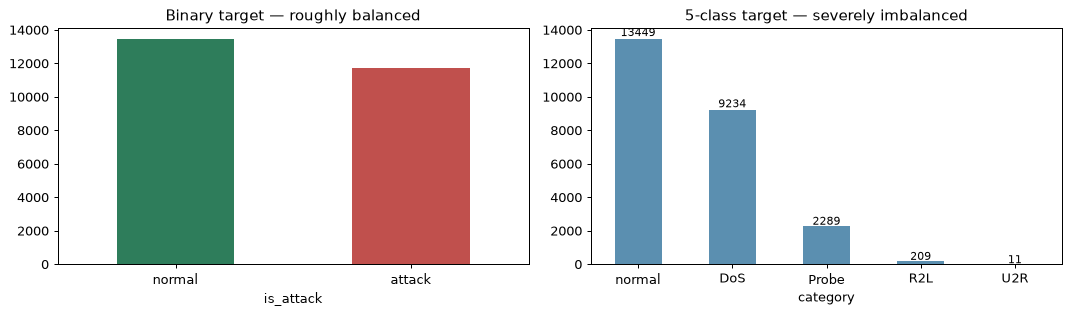

In [6]:
print('Binary balance (%):'); print((df['is_attack'].value_counts(normalize=True)*100).round(1))
print('\nBy category:'); print(df['category'].value_counts())
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df['is_attack'].map({0:'normal',1:'attack'}).value_counts().plot.bar(ax=ax[0], color=['#2E7D5B','#C0504D'])
ax[0].set_title('Binary target — roughly balanced'); ax[0].tick_params(axis='x', rotation=0)
df['category'].value_counts().plot.bar(ax=ax[1], color='#5B8FB0'); ax[1].set_title('5-class target — severely imbalanced'); ax[1].tick_params(axis='x', rotation=0)
for i,v in enumerate(df['category'].value_counts()): ax[1].text(i, v+v*0.01+50, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**C'est la difficulté centrale de tout le projet.** En regardant la cible binaire, on est à environ 53 % normal / 47 % attaque, ce qui est confortablement équilibré et facile à manipuler. Mais dès qu'on la décompose en 5 catégories, le déséquilibre devient brutal : `DoS` est énorme, tandis que `U2R` ne compte qu'une poignée d'exemples et `R2L` quelques centaines seulement. Nous le signalons tôt car cela explique presque tout ce qui pose problème par la suite — les classes rares (R2L, U2R) sont difficiles précisément parce qu'il y a très peu d'exemples pour apprendre, et ce déséquilibre est ce qui guide nos choix ultérieurs autour des poids de classes et des seuils.

### 1.3 Statistiques de base et le problème d'asymétrie (boîte à moustaches)

         src_bytes  dst_bytes    count  duration
count      25192.0    25192.0  25192.0   25192.0
mean       24330.6     3491.8     84.6     305.1
std      2410805.4    88830.7    114.7    2686.6
min            0.0        0.0      1.0       0.0
25%            0.0        0.0      2.0       0.0
50%           44.0        0.0     14.0       0.0
75%          279.0      530.2    144.0       0.0
max    381709090.0  5151385.0    511.0   42862.0

src_bytes: mean=24330.6  var=5811982686446.2  std=2410805.4  skew=157.6


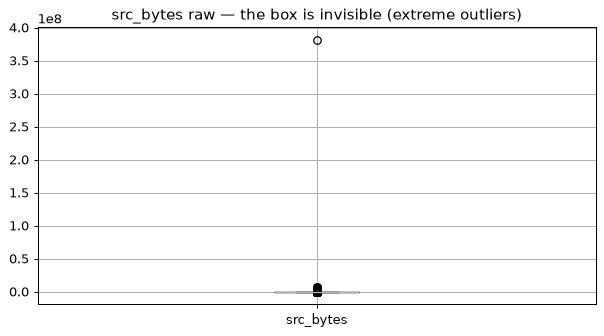

In [7]:
print(df[['src_bytes','dst_bytes','count','duration']].describe().round(1))
x=df['src_bytes']; print('\nsrc_bytes: mean=%.1f  var=%.1f  std=%.1f  skew=%.1f'%(x.mean(),x.var(),x.std(),x.skew()))
df.boxplot(column=['src_bytes']); plt.title('src_bytes raw — the box is invisible (extreme outliers)'); plt.show()

**Ce que l'on remarque :** `src_bytes` s'étend de 0 jusqu'à des millions, avec une asymétrie d'environ 150. Quelques connexions géantes dominent complètement et écrasent toutes les autres valeurs sur une seule ligne, si bien que la boîte elle-même est quasiment invisible. On en conclut qu'une variable de cette forme est inutilisable telle quelle pour un modèle — il faudra la transformer avant qu'elle puisse apporter quoi que ce soit, ce que nous reprenons en 1.7.

### 1.4 Les variables séparent-elles les classes ? (boîtes à moustaches par classe)

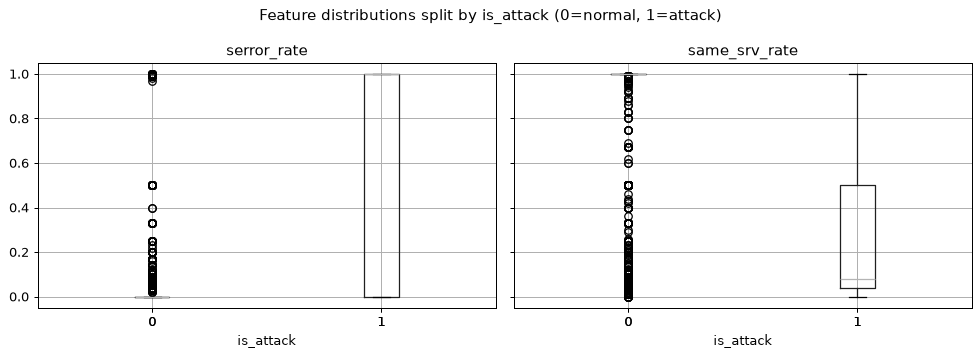

In [8]:
df.boxplot(column=['serror_rate','same_srv_rate'], by='is_attack', figsize=(11,4))
plt.suptitle('Feature distributions split by is_attack (0=normal, 1=attack)'); plt.tight_layout(); plt.show()

**Notre observation :** partout où la boîte « normal » et la boîte « attaque » se chevauchent à peine, la variable sépare bien les deux classes. `serror_rate` et `same_srv_rate` montrent toutes deux très peu de chevauchement entre les deux, donc on s'attend à ce que nos modèles s'appuient fortement dessus — elles nous semblent être de véritables prédicteurs solides.

### 1.5 Histogrammes — distributions, regroupement en classes, et forme par classe

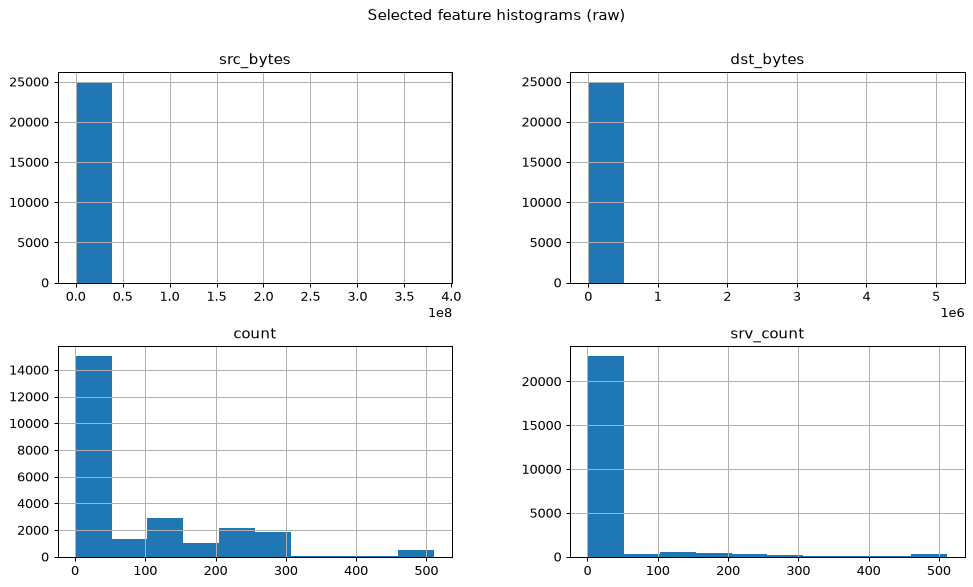

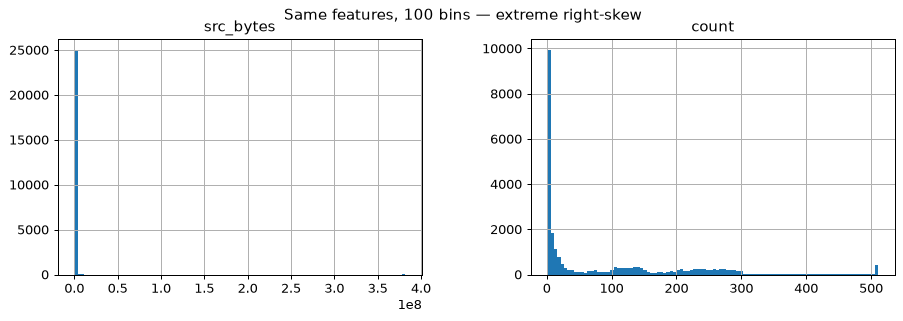

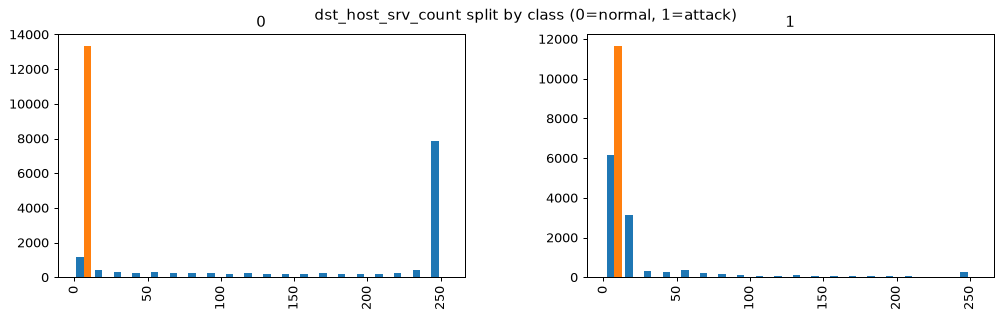

In [9]:
df_viz[['src_bytes','dst_bytes','count','srv_count']].hist(figsize=(13,7)); plt.suptitle('Selected feature histograms (raw)'); plt.show()
fig=df_viz[['src_bytes','count']].hist(bins=100, figsize=(12,3.4)); plt.suptitle('Same features, 100 bins — extreme right-skew'); plt.show()
df_viz[['dst_host_srv_count','is_attack']].hist(figsize=(13,3.6), by='is_attack', sharex=True, bins=20, layout=(1,2))
plt.suptitle('dst_host_srv_count split by class (0=normal, 1=attack)'); plt.show()

**Ce que les histogrammes nous disent :** les variables de magnitude brutes sont essentiellement un grand pic à 0 avec une longue queue fine vers la droite — une asymétrie à droite classique, qui renforce notre décision de les transformer en log. L'histogramme par classe est plus encourageant : `dst_host_srv_count` se situe à des valeurs *élevées* pour le trafic normal mais s'étale vers des valeurs *basses* pour les attaques, donc elle porte clairement une information que l'on peut exploiter.

### 1.6 Structure de corrélation (matrice de nuages de points + carte de chaleur)

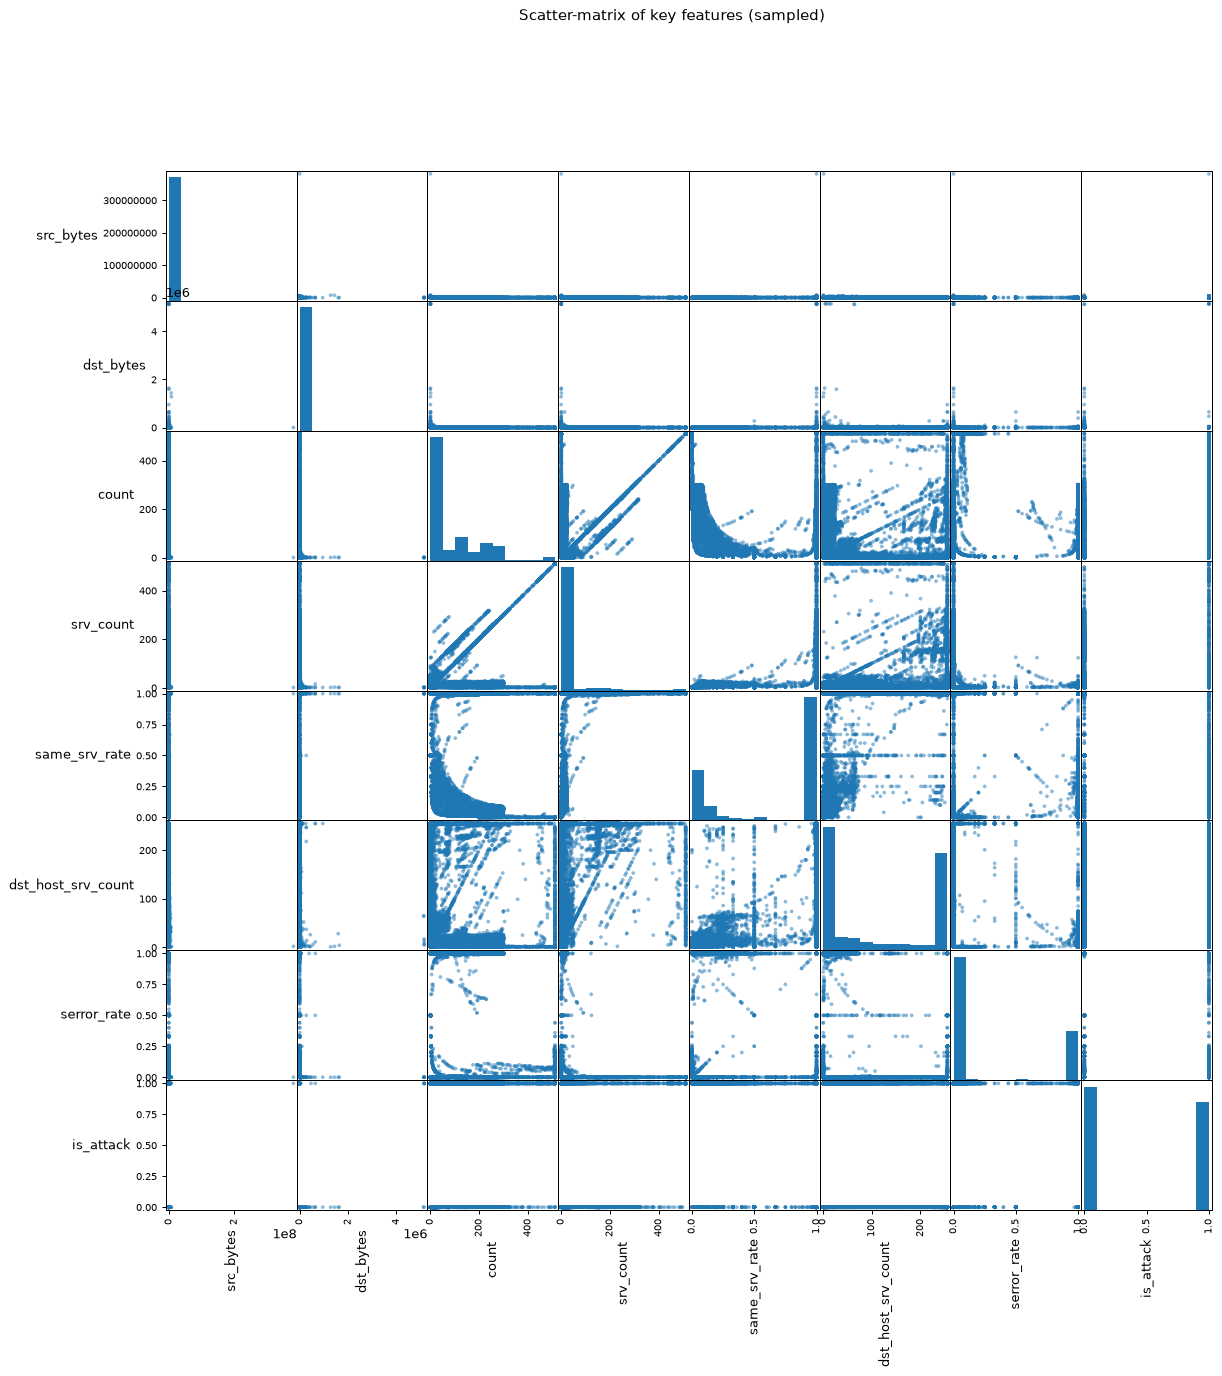

In [10]:
cols=['src_bytes','dst_bytes','count','srv_count','same_srv_rate','dst_host_srv_count','serror_rate','is_attack']
sm=scatter_matrix(df_viz[cols], figsize=(15,15)); rotate_labels(sm); plt.suptitle('Scatter-matrix of key features (sampled)', y=1.0); plt.show()

same_srv_rate <-> is_attack : -0.749
serror_rate   <-> srv_serror_rate (redundant pair!): 0.993


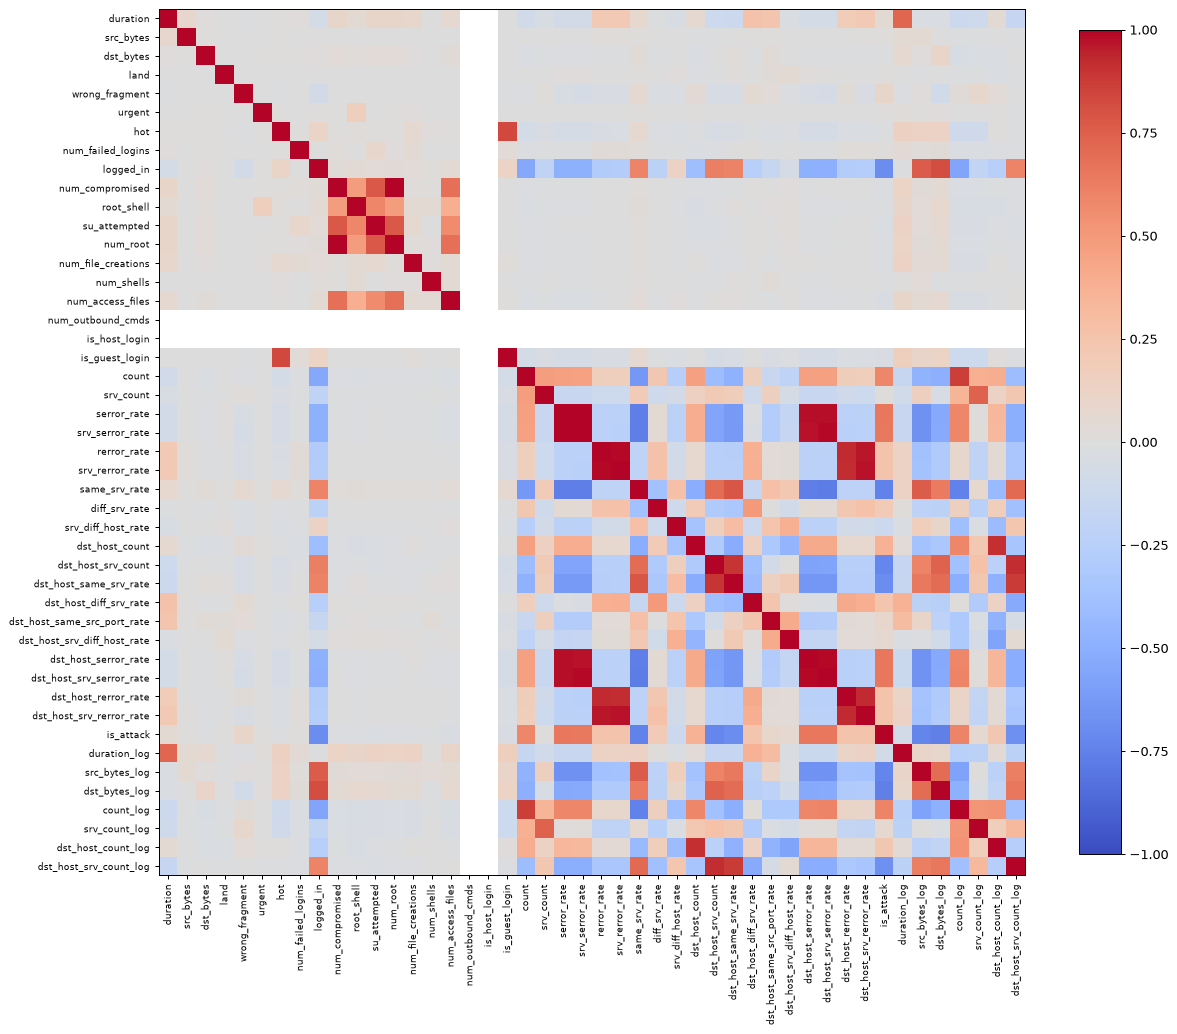

In [11]:
num_for_corr = df.select_dtypes(include=[np.number]).drop(columns=['level'])
print('same_srv_rate <-> is_attack :', round(num_for_corr.corr()['same_srv_rate']['is_attack'],3))
print('serror_rate   <-> srv_serror_rate (redundant pair!):', round(num_for_corr.corr()['serror_rate']['srv_serror_rate'],3))
plot_corr(num_for_corr, width=14, height=14)

**Ce qui nous saute aux yeux :** les blocs rouge vif — les familles `serror`/`rerror` et la famille `dst_host_*` — sont des groupes de variables presque identiques entre elles. Elles sont très redondantes, donc nous prévoyons de supprimer une variable de chaque paire quasi-dupliquée lors du prétraitement. Pour nous, cette carte de chaleur est l'argument visuel le plus clair pour réduire le jeu de variables.

### 1.7 Classement des variables par corrélation avec l'attaque — *avant* la transformation log

In [12]:
features_before = get_features_correlated_to_target(num_for_corr, target_feature='is_attack')
print('TOP 12 features by |correlation| with is_attack (BEFORE log):'); print(features_before.head(12).round(3))

TOP 12 features by |correlation| with is_attack (BEFORE log):
dst_bytes_log               0.753
same_srv_rate               0.749
src_bytes_log               0.729
dst_host_srv_count          0.719
dst_host_same_srv_rate      0.692
logged_in                   0.688
dst_host_srv_count_log      0.675
dst_host_srv_serror_rate    0.654
dst_host_serror_rate        0.651
serror_rate                 0.650
srv_serror_rate             0.648
count_log                   0.599
Name: is_attack, dtype: float64


**Un résultat que nous avons trouvé véritablement surprenant.** Le haut de notre classement est mené par `same_srv_rate`, `dst_host_srv_count`, `logged_in` et la famille `serror_rate` — rien à redire. Ce qui a attiré notre attention, c'est que `src_bytes` et `dst_bytes` se trouvent tout en *bas* (|corr| ≈ 0,01), alors qu'intuitivement la quantité de données envoyées devrait compter énormément pour repérer une attaque. On n'a pas pris cela pour argent comptant — et la transformation log dans les sections suivantes nous montre exactement pourquoi la corrélation brute nous induisait en erreur.

### 1.8 LE résultat clé — la transformation log dévoile des prédicteurs cachés

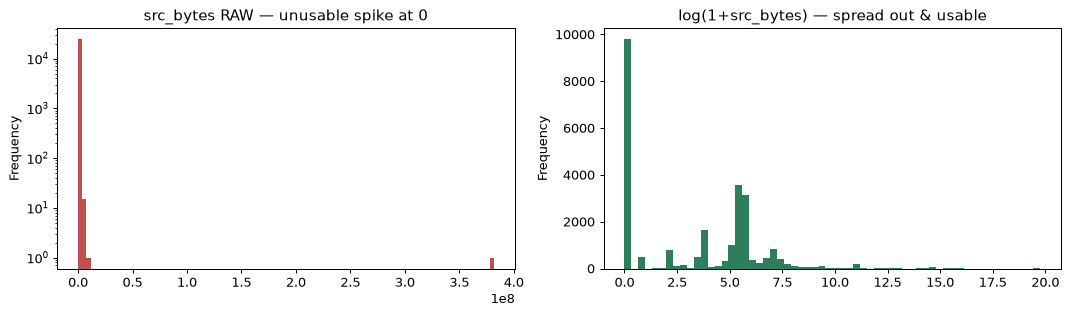

Original  src_bytes <-> is_attack : 0.006
After log src_bytes <-> is_attack : -0.729


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df_viz['src_bytes'].plot.hist(bins=100, ax=ax[0], color='#C0504D'); ax[0].set_yscale('log'); ax[0].set_title('src_bytes RAW — unusable spike at 0')
np.log1p(df_viz['src_bytes']).plot.hist(bins=60, ax=ax[1], color='#2E7D5B'); ax[1].set_title('log(1+src_bytes) — spread out & usable')
plt.tight_layout(); plt.show()
corr=df.corr(numeric_only=True)
print('Original  src_bytes <-> is_attack :', round(corr['src_bytes']['is_attack'],3))
print('After log src_bytes <-> is_attack :', round(corr['src_bytes_log']['is_attack'],3))

**C'est la chose la plus importante que nous ayons découverte dans toute l'exploration.** Brute, `src_bytes` est corrélée à environ **0,01** avec l'étiquette d'attaque — autant dire rien. Mais une fois qu'on applique `log(1+x)`, cela bondit à environ **0,73** (et c'est négatif — des comptes d'octets plus élevés vont avec le trafic *normal*). La relation était là depuis le début ; les valeurs extrêmes la masquaient simplement. Ce sont les mêmes données, juste remises en forme. C'est cette seule découverte qui justifie que l'on transforme en log `src_bytes`, `dst_bytes`, `count` et les autres variables de magnitude tout au long du projet.

### 1.9 Classement des variables *après* la transformation log

In [14]:
num_after = df.select_dtypes(include=[np.number]).drop(columns=['level'])
features_after = get_features_correlated_to_target(num_after, target_feature='is_attack')
print('TOP 10 AFTER log transform:'); print(features_after.head(10).round(3))

TOP 10 AFTER log transform:
dst_bytes_log               0.753
same_srv_rate               0.749
src_bytes_log               0.729
dst_host_srv_count          0.719
dst_host_same_srv_rate      0.692
logged_in                   0.688
dst_host_srv_count_log      0.675
dst_host_srv_serror_rate    0.654
dst_host_serror_rate        0.651
serror_rate                 0.650
Name: is_attack, dtype: float64


**Ce qui a changé :** après les avoir passées au log, `src_bytes` et `dst_bytes` montent directement parmi nos meilleures variables — des prédicteurs qui étaient invisibles un instant plus tôt. Nous trouvons ce résultat satisfaisant car cela signifie qu'on a *créé* un signal utile uniquement par le prétraitement, sans toucher au modèle. C'est le jeu de 10 variables que nos modèles utilisent ensuite.

# Partie 1B — Prétraitement & nettoyage (notre pipeline)

Notre exploration a révélé trois problèmes corrigeables, donc dans cette section nous appliquons chaque correction et *montrons son effet* plutôt que de simplement affirmer qu'elle fonctionne :
1. **Variables constantes** → on les supprime (elles ne portent aucune information).
2. **Variables redondantes** (les blocs rouges de la carte de chaleur) → on supprime une variable de chaque paire quasi-dupliquée.
3. **Variables de magnitude asymétriques** → on les transforme en log.
Ensuite, nous encodons en one-hot les colonnes textuelles et nous découpons les données.

In [15]:
ORIGINAL_FEATURES = COL_NAMES[:41]
df_clean = df[ORIGINAL_FEATURES + ['attack','category','is_attack']].copy()
n_raw = len(ORIGINAL_FEATURES); print('Starting from', n_raw, 'raw features | df_clean:', df_clean.shape)

Starting from 41 raw features | df_clean: (25192, 44)


### Étape 1 — supprimer les variables constantes (aucune information)

In [16]:
constant=[c for c in df_clean.select_dtypes(include=[np.number]).columns if df_clean[c].nunique()==1]
print('Constant columns:', constant)
df_clean=df_clean.drop(columns=constant); n_after_const=n_raw-len(constant)
print(f'Features: {n_raw} -> {n_after_const}  (dropped {len(constant)})')

Constant columns: ['num_outbound_cmds', 'is_host_login']
Features: 41 -> 39  (dropped 2)


**Notre raisonnement :** une colonne qui contient la même valeur sur chaque ligne (ici `num_outbound_cmds`, toujours à 0) ne peut aider aucun modèle à distinguer quoi que ce soit, donc on la supprime aussitôt.

### Étape 2 — supprimer les variables redondantes (quasi-dupliquées)

In [17]:
def find_redundant(frame, threshold=0.95, target='is_attack'):
    num=frame.select_dtypes(include=[np.number]); corr=num.corr().abs(); tgt=corr[target]
    upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)); report,to_drop=[],set()
    for f1 in upper.columns:
        for f2 in upper.index:
            r=upper.loc[f2,f1]
            if pd.notna(r) and r>threshold and target not in (f1,f2):
                loser=f2 if tgt[f2]<=tgt[f1] else f1
                report.append((f2,f1,round(r,3),loser)); to_drop.add(loser)
    return report, sorted(to_drop)
report, redundant = find_redundant(df_clean, threshold=0.95)
print('Highly-correlated pairs (|r|>0.95) and the decision:')
for f2,f1,r,loser in report: print(f'  {f2:26s} <-> {f1:26s} r={r} -> drop {loser}')
df_clean=df_clean.drop(columns=redundant); n_after_dedup=n_after_const-len(redundant)
print(f'\nFeatures: {n_after_const} -> {n_after_dedup}  (dropped {len(redundant)} redundant)')

Highly-correlated pairs (|r|>0.95) and the decision:
  num_compromised            <-> num_root                   r=0.999 -> drop num_compromised
  serror_rate                <-> srv_serror_rate            r=0.993 -> drop srv_serror_rate
  rerror_rate                <-> srv_rerror_rate            r=0.989 -> drop srv_rerror_rate
  serror_rate                <-> dst_host_serror_rate       r=0.978 -> drop serror_rate
  srv_serror_rate            <-> dst_host_serror_rate       r=0.976 -> drop srv_serror_rate
  serror_rate                <-> dst_host_srv_serror_rate   r=0.98 -> drop serror_rate
  srv_serror_rate            <-> dst_host_srv_serror_rate   r=0.985 -> drop srv_serror_rate
  dst_host_serror_rate       <-> dst_host_srv_serror_rate   r=0.985 -> drop dst_host_serror_rate
  rerror_rate                <-> dst_host_srv_rerror_rate   r=0.965 -> drop rerror_rate
  srv_rerror_rate            <-> dst_host_srv_rerror_rate   r=0.97 -> drop srv_rerror_rate

Features: 39 -> 33  (dropped 6 redu

**Comment nous décidons laquelle supprimer :** pour chaque paire quasi-dupliquée, on garde celle qui est la *plus* corrélée à l'étiquette d'attaque et on supprime l'autre. Ainsi, on élimine la redondance que montraient ces blocs rouges sans jeter aucune information prédictive réelle.

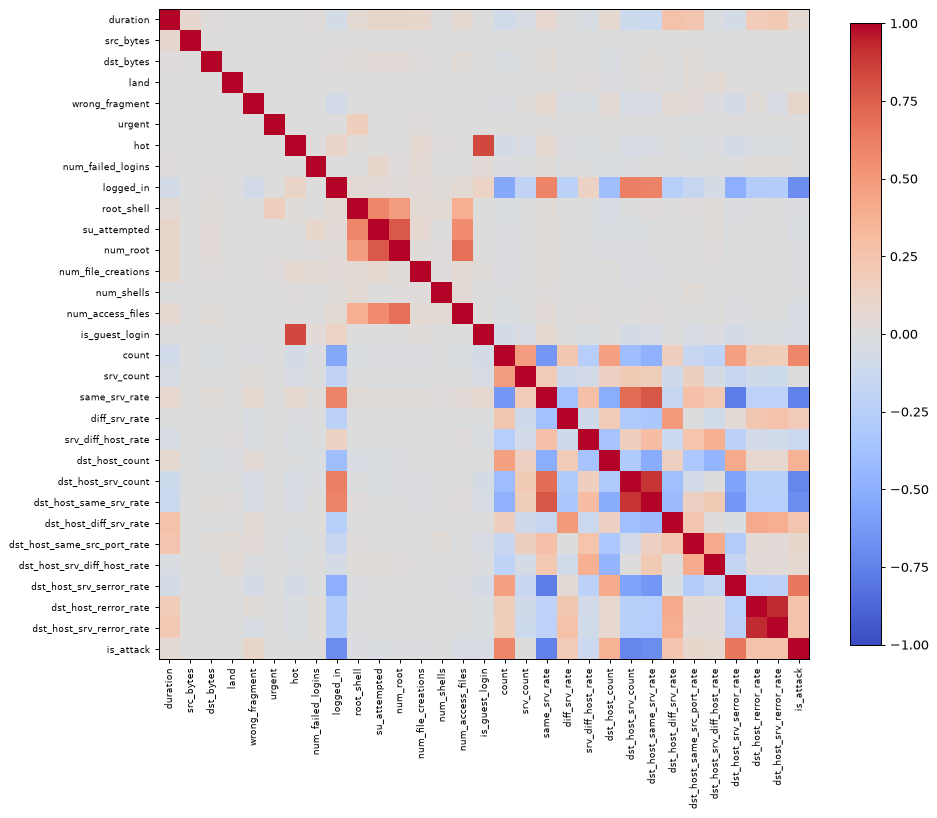

In [18]:
plot_corr(df_clean.select_dtypes(include=[np.number]), width=11, height=11)

**Le bénéfice, et on le voit directement.** En comparant cette carte de chaleur avec celle de la section 1.6, les blocs rouges denses `serror`/`rerror` ont disparu. Les variables qui nous restent sont bien moins redondantes — un jeu plus propre et plus épuré, bien mieux adapté à la modélisation.

### Étape 3 — transformer en log les variables de magnitude asymétriques (tableau avant/après)

In [19]:
to_log=['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count','num_root','hot','num_file_creations','num_access_files']
to_log=[c for c in to_log if c in df_clean.columns]
before=pd.DataFrame({'skew_before':df_clean[to_log].skew().round(1),
                     'corr_target_before':df_clean[to_log+['is_attack']].corr()['is_attack'][to_log].round(3)})
for c in to_log: df_clean[c]=np.log1p(df_clean[c])
after=pd.DataFrame({'skew_after':df_clean[to_log].skew().round(1),
                    'corr_target_after':df_clean[to_log+['is_attack']].corr()['is_attack'][to_log].round(3)})
print(before.join(after)[['skew_before','skew_after','corr_target_before','corr_target_after']])

                    skew_before  skew_after  corr_target_before  \
duration                   11.5         5.2               0.051   
src_bytes                 157.6         0.3               0.006   
dst_bytes                  54.8         0.5              -0.011   
count                       1.5         0.1               0.579   
srv_count                   4.7         0.9               0.002   
dst_host_count             -0.8        -1.7               0.369   
dst_host_srv_count          0.3        -0.4              -0.719   
num_root                   62.3        24.3              -0.020   
hot                        13.6         9.4              -0.013   
num_file_creations         52.1        30.6              -0.018   
num_access_files           41.8        22.6              -0.037   

                    corr_target_after  
duration                       -0.070  
src_bytes                      -0.729  
dst_bytes                      -0.753  
count                           0.5

**Lecture de notre tableau avant/après :** `src_bytes` passe d'une asymétrie ≈ 150 et |corr| ≈ 0,01 à une asymétrie maîtrisée et |corr| ≈ 0,73, et `dst_bytes` se comporte de la même façon. On a effectivement dévoilé de solides prédicteurs qui étaient enfouis dans les données brutes. Quelques variables bougent à peine, ce qui est normal — nous avons décidé de transformer chaque variable au cas par cas plutôt que d'appliquer la transformation aveuglément à toutes.

### Finalisation — encoder les colonnes textuelles, vérifier les valeurs manquantes, découper

In [20]:
print('total missing values:', df_clean.isnull().sum().sum(), '(NSL-KDD is clean)')
df_encoded=pd.get_dummies(df_clean, columns=['protocol_type','flag','service'], prefix=['protocol_type','flag','service'])
n_onehot=df_encoded.drop(columns=['attack','category','is_attack']).shape[1]
print(f'one-hot encoding: {n_after_dedup} numeric features -> {n_onehot} columns (text expanded)')
Xc=df_encoded.drop(columns=[c for c in ['attack','category','is_attack'] if c in df_encoded]).select_dtypes(include=[np.number,'bool']).astype(float)
Xtr_c2,Xte_c2,ytr2,yte2=train_test_split(Xc, df_encoded['is_attack'], test_size=0.25, random_state=42, stratify=df_encoded['is_attack'])
print('split -> X_train', Xtr_c2.shape, '| X_test', Xte_c2.shape)
print('\n=== PREPROCESSING PIPELINE SUMMARY ===')
print(f'{"raw features":32s}: {n_raw}')
print(f'{"after dropping constants":32s}: {n_after_const}  (-{n_raw-n_after_const})')
print(f'{"after dropping redundant":32s}: {n_after_dedup}  (-{n_after_const-n_after_dedup})')
print(f'{"after one-hot encoding":32s}: {n_onehot}  (text expanded)')
print(f'{"log-transformed in place":32s}: {len(to_log)} features')

total missing values: 0 (NSL-KDD is clean)
one-hot encoding: 33 numeric features -> 110 columns (text expanded)
split -> X_train (18894, 110) | X_test (6298, 110)

=== PREPROCESSING PIPELINE SUMMARY ===
raw features                    : 41
after dropping constants        : 39  (-2)
after dropping redundant        : 33  (-6)
after one-hot encoding          : 110  (text expanded)
log-transformed in place        : 11 features


**Notre pipeline de nettoyage complet en un coup d'œil.** Nous sommes partis de 41 variables brutes, on a supprimé les constantes, supprimé les doublons redondants, transformé en log les variables asymétriques, et encodé en one-hot les colonnes textuelles. Le résultat est une table de variables propre, non redondante et bien mise à l'échelle, prête pour la modélisation.

# Comment lire chaque résultat ci-dessous

À partir d'ici, **chaque précision et chaque matrice de confusion est en Entraînement→Test** : on entraîne sur `KDDTrain` et on évalue sur le `KDDTest+` jamais vu. Ce sont nos chiffres *honnêtes*, et tout est calculé directement sur le jeu de données NSL-KDD.

## Matrices de confusion ENTRAÎNEMENT vs TEST

Pour chaque modèle ci-dessous, nous affichons deux matrices de confusion : une sur les **données d'entraînement** (déjà vues par le modèle, juste après l'entraînement) et une sur le **`KDDTest+`** (jamais vu). L'écart entre les deux est la clé : si un modèle réussit à gauche mais s'effondre à droite sur R2L/U2R, le problème vient de la **généralisation**, pas de l'apprentissage. La fonction `cm_train_test` ci-dessous produit cette comparaison.

In [21]:
# === Metriques par modele : precision, rappel, F1, exactitude (accuracy), total ===
from sklearn.metrics import precision_score, recall_score
def metrics_report(y_true, y_pred, name, target_names=None):
    """Affiche un tableau clair : precision / rappel / F1 / support par classe,
    puis l'exactitude globale et les moyennes (macro et ponderee = 'total')."""
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"========== {name} ==========")
    print(f"  Exactitude (accuracy) GLOBALE : {acc:.3f}")
    print(f"  F1 macro : {f1m:.3f}   |   F1 ponderee (total) : {f1w:.3f}\n")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3, zero_division=0))
    print()

# === Matrices de confusion ENTRAINEMENT vs TEST (5 classes) ===
CAT_ORDER = ['normal','DoS','Probe','R2L','U2R']
def cm_train_test(model, Xtr, ytr_true, Xte, yte_true, name):
    """Matrice ENTRAINEMENT (vu) vs TEST (jamais vu) + metriques completes sur le TEST."""
    ptr, pte = model.predict(Xtr), model.predict(Xte)
    labels = [c for c in CAT_ORDER if c in set(ytr_true) | set(yte_true)]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    ConfusionMatrixDisplay.from_predictions(ytr_true, ptr, labels=labels, normalize='true',
                                            cmap='Blues', xticks_rotation=45, ax=ax[0], colorbar=False)
    ax[0].set_title(f'{name} - ENTRAINEMENT (KDDTrain) [donnees vues]')
    ConfusionMatrixDisplay.from_predictions(yte_true, pte, labels=labels, normalize='true',
                                            cmap='Blues', xticks_rotation=45, ax=ax[1], colorbar=False)
    ax[1].set_title(f'{name} - TEST (KDDTest+) [jamais vu]')
    plt.tight_layout(); plt.show()
    # rappel entrainement -> test (rapide a lire)
    for lab in labels:
        mtr = (np.asarray(ytr_true) == lab); mte = (np.asarray(yte_true) == lab)
        rtr = (ptr[mtr] == lab).mean() if mtr.sum() else float('nan')
        rte = (pte[mte] == lab).mean() if mte.sum() else float('nan')
        print(f'  {name:16s} | {lab:7s}: rappel ENTRAINEMENT {rtr:.2f}  ->  TEST {rte:.2f}')
    print()
    # tableau complet des metriques sur le TEST (precision / rappel / F1 / total)
    metrics_report(yte_true, pte, name + ' - metriques sur le TEST')


# Régression linéaire (référence)

### 2.1 La régression linéaire comme classifieur rudimentaire (Entraînement→Test)

In [22]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression().fit(dtr[BASE], ytr)
acc_linear = accuracy_score(yte, (lin.predict(dte[BASE]) > 0.5).astype(int))
print('linear regression + 0.5 threshold | TEST accuracy =', round(acc_linear, 3))
metrics_report(yte, (lin.predict(dte[BASE]) > 0.5).astype(int),
                'Regression lineaire (binaire)', target_names=['normal','attaque'])

linear regression + 0.5 threshold | TEST accuracy = 0.743
========== Regression lineaire (binaire) ==========
  Exactitude (accuracy) GLOBALE : 0.743
  F1 macro : 0.741   |   F1 ponderee (total) : 0.738

              precision    recall  f1-score   support

      normal      0.632     0.963     0.764      9711
     attaque      0.954     0.576     0.719     12833

    accuracy                          0.743     22544
   macro avg      0.793     0.770     0.741     22544
weighted avg      0.816     0.743     0.738     22544




**Ce que l'on obtient :** même une simple droite atteint environ **0,74** sur le test réel. C'est la mauvaise forme pour une cible 0/1 — elle ne nous donne pas de vraies probabilités — mais on l'utilise délibérément comme référence honnête que tout modèle ultérieur doit battre.

### 2.2 La transformation log améliore une variable (illustration sur les données d'entraînement)

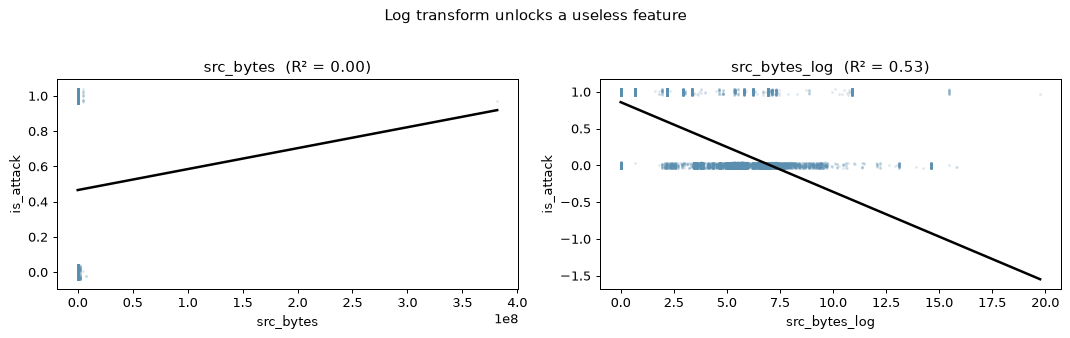

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, feat in zip(ax, ['src_bytes', 'src_bytes_log']):
    a.scatter(df[feat], df['is_attack']+(np.random.RandomState(0).rand(len(df))-0.5)*0.08, s=2, alpha=0.12, color='#5B8FB0')
    mm=LinearRegression().fit(df[[feat]], df['is_attack']); r2=mm.score(df[[feat]], df['is_attack'])
    xs=np.linspace(df[feat].min(), df[feat].max(), 100); a.plot(xs, mm.predict(xs.reshape(-1,1)), color='black', lw=2)
    a.set(xlabel=feat, ylabel='is_attack', title=f'{feat}  (R² = {r2:.2f})')
plt.suptitle('Log transform unlocks a useless feature', y=1.03); plt.tight_layout(); plt.show()

**Le même gain de prétraitement, montré cette fois à l'intérieur d'un modèle.** Brute, `src_bytes` n'explique presque rien (R²≈0) ; une fois passée au log, cette même variable atteint R²≈0,5. C'est le résultat de l'exploration de la Partie 1 qui se concrétise directement dans un modèle ajusté — ici sur les données d'entraînement, juste pour rendre l'effet visible.

# Régression logistique

### 3.1 Biais–variance, montré en Entraînement→Test

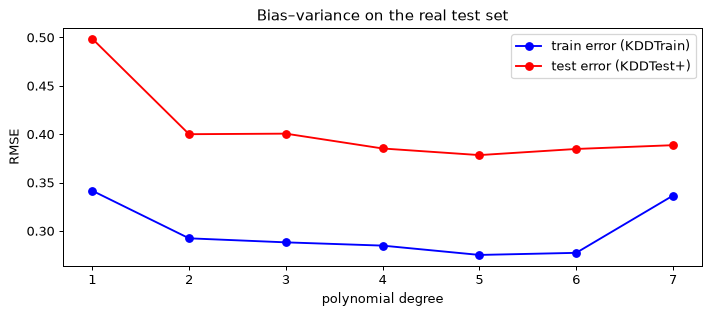

In [24]:
from sklearn.preprocessing import PolynomialFeatures
deg=range(1,8); tr_e=[]; te_e=[]
for p in deg:
    mod=make_pipeline(PolynomialFeatures(p), LinearRegression()).fit(dtr[['src_bytes_log']], ytr)
    tr_e.append(mean_squared_error(ytr, mod.predict(dtr[['src_bytes_log']]))**.5)
    te_e.append(mean_squared_error(yte, mod.predict(dte[['src_bytes_log']]))**.5)
fig,ax=plt.subplots(figsize=(8,3.6))
ax.plot(list(deg),tr_e,'o-',color='blue',label='train error (KDDTrain)')
ax.plot(list(deg),te_e,'o-',color='red',label='test error (KDDTest+)')
ax.set(xlabel='polynomial degree', ylabel='RMSE', title='Bias–variance on the real test set'); ax.legend()
plt.tight_layout(); plt.show()

**Ce que cette courbe nous dit sur le surapprentissage :** notre erreur d'entraînement continue de baisser à mesure qu'on augmente le degré du polynôme, mais l'erreur de test *réelle* stagne puis commence à remonter. Cet écart qui se creuse est du surapprentissage, et comme on le mesure contre les attaques inédites du `KDDTest+`, on le voit honnêtement plutôt que de le masquer derrière un découpage aléatoire.

### 3.2 Matrices de confusion Entraînement→Test — binaire et 5 classes

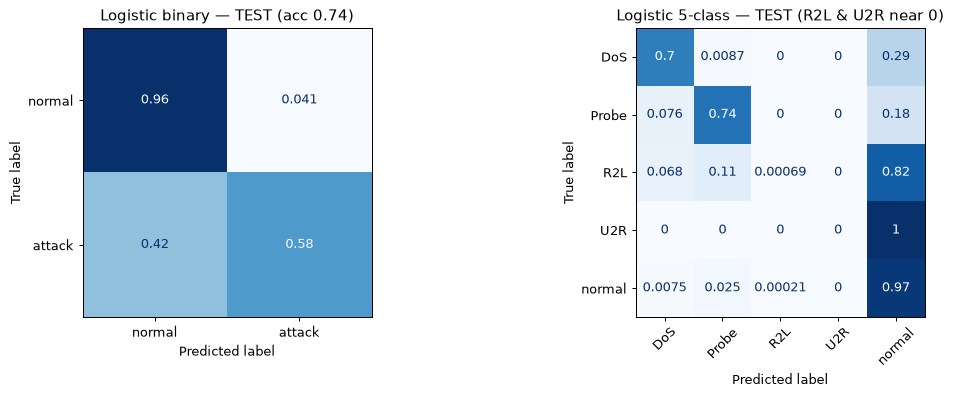

========== Regression logistique (binaire) ==========
  Exactitude (accuracy) GLOBALE : 0.743
  F1 macro : 0.741   |   F1 ponderee (total) : 0.738

              precision    recall  f1-score   support

      normal      0.633     0.959     0.763      9711
     attaque      0.949     0.579     0.719     12833

    accuracy                          0.743     22544
   macro avg      0.791     0.769     0.741     22544
weighted avg      0.813     0.743     0.738     22544




In [25]:
log_bin=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=2000)).fit(dtr[BASE],ytr)
log_mc =make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)).fit(dtr_c[BASE],ytr_c)
acc_logistic=accuracy_score(yte,log_bin.predict(dte[BASE]))
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(yte,log_bin.predict(dte[BASE]),display_labels=['normal','attack'],normalize='true',cmap='Blues',ax=ax[0],colorbar=False)
ax[0].set_title(f'Logistic binary — TEST (acc {acc_logistic:.2f})')
ConfusionMatrixDisplay.from_predictions(yte_c,log_mc.predict(dte_c[BASE]),normalize='true',cmap='Blues',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('Logistic 5-class — TEST (R2L & U2R near 0)'); plt.tight_layout(); plt.show()
metrics_report(yte, log_bin.predict(dte[BASE]),
                'Regression logistique (binaire)', target_names=['normal','attaque'])

**Entraînement vs test — régression logistique.** Modèle linéaire : il généralise modérément. R2L tombe de ~0,33 (entraînement) à 0,00 (test), et U2R reste à 0 des deux côtés (trop peu d'exemples, même pour l'apprendre).

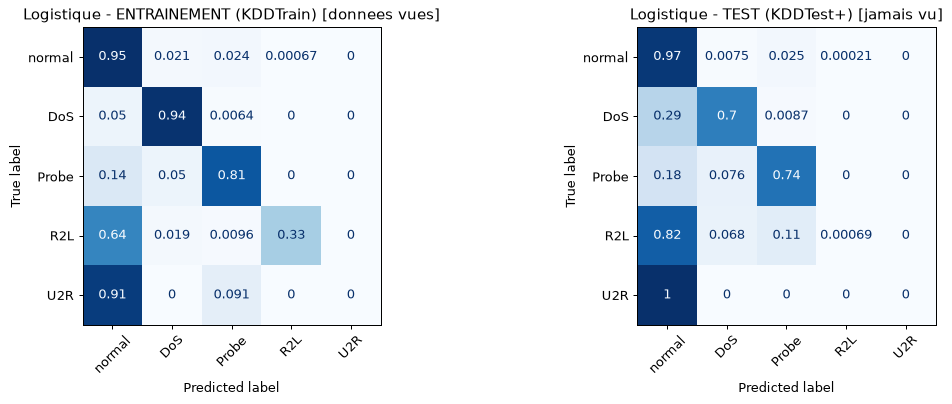

  Logistique       | normal : rappel ENTRAINEMENT 0.95  ->  TEST 0.97
  Logistique       | DoS    : rappel ENTRAINEMENT 0.94  ->  TEST 0.70
  Logistique       | Probe  : rappel ENTRAINEMENT 0.81  ->  TEST 0.74
  Logistique       | R2L    : rappel ENTRAINEMENT 0.33  ->  TEST 0.00
  Logistique       | U2R    : rappel ENTRAINEMENT 0.00  ->  TEST 0.00

========== Logistique - metriques sur le TEST ==========
  Exactitude (accuracy) GLOBALE : 0.728
  F1 macro : 0.463   |   F1 ponderee (total) : 0.677

              precision    recall  f1-score   support

         DoS      0.920     0.698     0.794      7460
       Probe      0.744     0.742     0.743      2421
         R2L      0.500     0.001     0.001      2885
         U2R      0.000     0.000     0.000        67
      normal      0.649     0.967     0.777      9711

    accuracy                          0.728     22544
   macro avg      0.563     0.482     0.463     22544
weighted avg      0.728     0.728     0.677     22544




In [26]:
cm_train_test(log_mc, dtr_c[BASE], ytr_c, dte_c[BASE], yte_c, 'Logistique')


**Le portrait honnête en deux matrices.** Sur le test réel, notre modèle logistique obtient environ **0,74** sur la tâche binaire. La matrice à 5 classes est là où la dure vérité apparaît : les **lignes R2L et U2R sont essentiellement vides** — ces attaques rares, dont beaucoup sont inédites, sont tout simplement manquées. On préfère de loin le montrer clairement plutôt que de le dissimuler.

# Réseau de neurones (MLP)

### 4.1 Le MLP sur le test réel (binaire + 5 classes)

MLP binary | TEST accuracy = 0.79


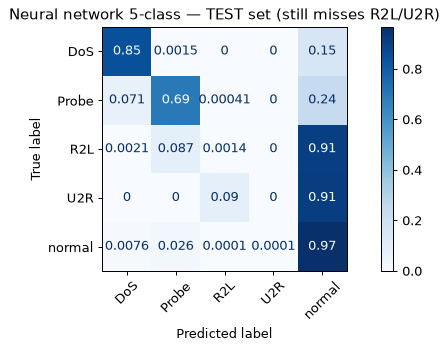

========== Reseau de neurones MLP (binaire) ==========
  Exactitude (accuracy) GLOBALE : 0.790
  F1 macro : 0.789   |   F1 ponderee (total) : 0.788

              precision    recall  f1-score   support

      normal      0.680     0.968     0.799      9711
     attaque      0.964     0.655     0.780     12833

    accuracy                          0.790     22544
   macro avg      0.822     0.812     0.789     22544
weighted avg      0.842     0.790     0.788     22544




In [27]:
mlp_bin=make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(dtr[BASE],ytr)
mlp_mc =make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(dtr_c[BASE],ytr_c)
acc_mlp=accuracy_score(yte,mlp_bin.predict(dte[BASE]))
print('MLP binary | TEST accuracy =', round(acc_mlp,3))
ConfusionMatrixDisplay.from_predictions(yte_c,mlp_mc.predict(dte_c[BASE]),normalize='true',cmap='Blues',xticks_rotation=45)
plt.title('Neural network 5-class — TEST set (still misses R2L/U2R)'); plt.tight_layout(); plt.show()
metrics_report(yte, mlp_bin.predict(dte[BASE]),
                'Reseau de neurones MLP (binaire)', target_names=['normal','attaque'])

**Entraînement vs test — réseau de neurones (MLP).** Plus flexible : à l'entraînement il apprend bien R2L (0,91) et un peu U2R (0,36), mais les deux tombent à 0,00 sur le test. C'est la preuve directe que le problème n'est pas l'apprentissage, mais la généralisation aux attaques inédites.

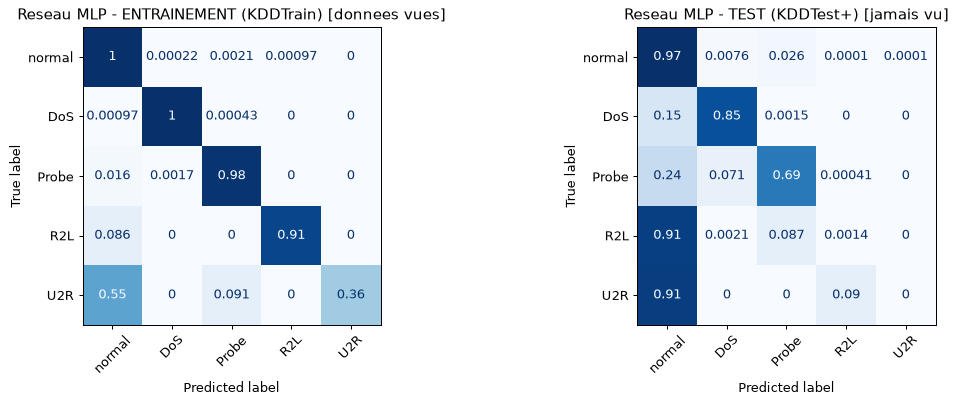

  Reseau MLP       | normal : rappel ENTRAINEMENT 1.00  ->  TEST 0.97
  Reseau MLP       | DoS    : rappel ENTRAINEMENT 1.00  ->  TEST 0.85
  Reseau MLP       | Probe  : rappel ENTRAINEMENT 0.98  ->  TEST 0.69
  Reseau MLP       | R2L    : rappel ENTRAINEMENT 0.91  ->  TEST 0.00
  Reseau MLP       | U2R    : rappel ENTRAINEMENT 0.36  ->  TEST 0.00

========== Reseau MLP - metriques sur le TEST ==========
  Exactitude (accuracy) GLOBALE : 0.771
  F1 macro : 0.486   |   F1 ponderee (total) : 0.721

              precision    recall  f1-score   support

         DoS      0.962     0.847     0.901      7460
       Probe      0.766     0.691     0.726      2421
         R2L      0.333     0.001     0.003      2885
         U2R      0.000     0.000     0.000        67
      normal      0.681     0.967     0.799      9711

    accuracy                          0.771     22544
   macro avg      0.548     0.501     0.486     22544
weighted avg      0.737     0.771     0.721     22544




In [28]:
cm_train_test(mlp_mc, dtr_c[BASE], ytr_c, dte_c[BASE], yte_c, 'Reseau MLP')


**Notre meilleur modèle — et sa limite.** Le MLP atteint environ **0,79** sur la tâche binaire, marginalement le meilleur de tout ce qu'on a essayé sur le test réel. Mais il échoue *quand même* sur R2L/U2R. C'est un constat important pour nous : un modèle plus puissant ne résout pas à lui seul le problème des attaques inédites. Les seules choses qui aident vraiment sont de voir ces attaques (des données plus représentatives) ou un seuil sensible au coût, que nous construisons à la fin du notebook.

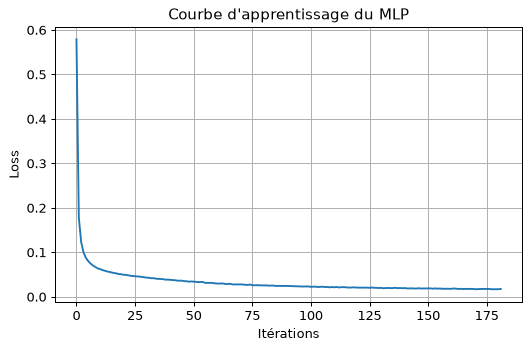

In [29]:
# Courbe d'apprentissage du MLP 5 classes
mlp_model = mlp_mc.named_steps['mlpclassifier']

plt.figure(figsize=(6,4))
plt.plot(mlp_model.loss_curve_)
plt.xlabel("Itérations")
plt.ylabel("Loss")
plt.title("Courbe d'apprentissage du MLP")
plt.grid(True)
plt.tight_layout()
plt.show()

# Arbres & méthodes d'ensemble

### 5.1 L'arbre de décision comme règles lisibles (entraîné sur KDDTrain)

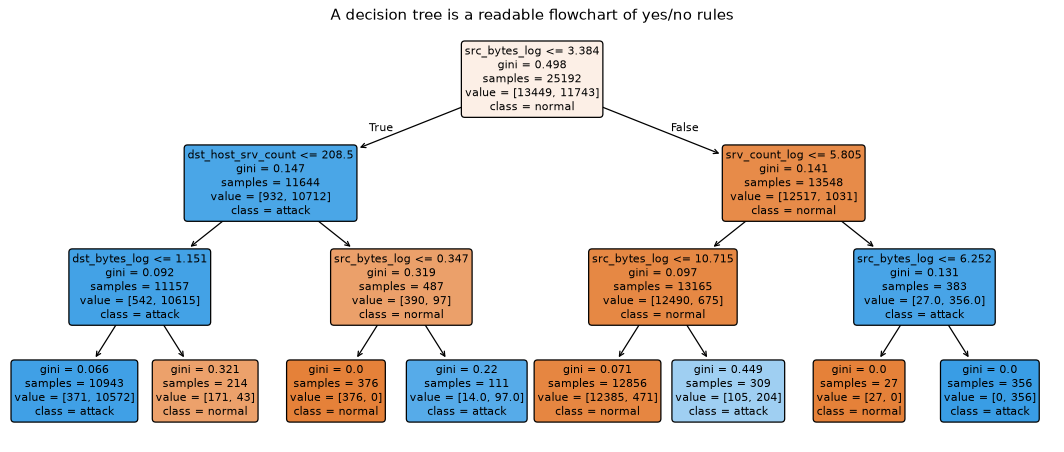

In [30]:
from sklearn.tree import plot_tree
tiny=DecisionTreeClassifier(max_depth=3,random_state=0).fit(dtr[BASE],ytr)
fig,ax=plt.subplots(figsize=(15,6))
plot_tree(tiny,feature_names=BASE,class_names=['normal','attack'],filled=True,rounded=True,fontsize=9,ax=ax)
plt.title('A decision tree is a readable flowchart of yes/no rules'); plt.show()

**Pourquoi on aime l'arbre :** il est entièrement lisible par un humain. On peut suivre les règles oui/non et voir *pourquoi* il signale une connexion donnée. Cette interprétabilité est gratuite, et c'est une grande raison pour laquelle nous penchons vers un modèle à base d'arbres pour notre détecteur final.

### 5.2 Surapprentissage (Entraînement→Test) et le plateau du nombre d'arbres

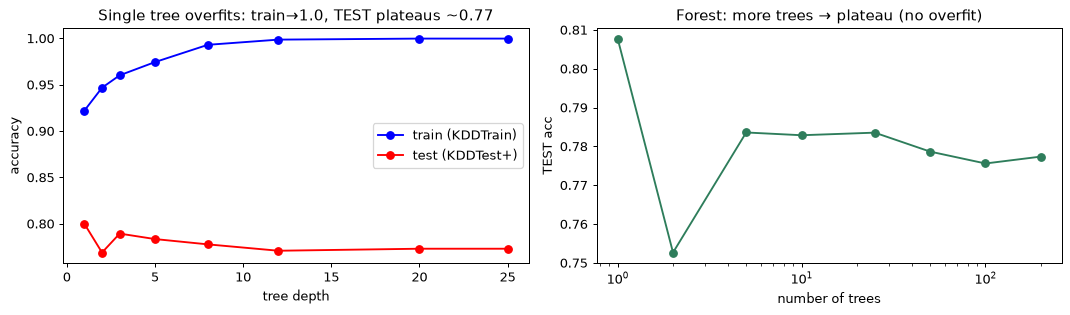

In [31]:
depths=[1,2,3,5,8,12,20,None]
tr_a=[accuracy_score(ytr,DecisionTreeClassifier(max_depth=d,random_state=0).fit(dtr[BASE],ytr).predict(dtr[BASE])) for d in depths]
te_a=[accuracy_score(yte,DecisionTreeClassifier(max_depth=d,random_state=0).fit(dtr[BASE],ytr).predict(dte[BASE])) for d in depths]
ns=[1,2,5,10,25,50,100,200]
n_acc=[accuracy_score(yte,RandomForestClassifier(n_estimators=n,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])) for n in ns]
fig,ax=plt.subplots(1,2,figsize=(12,3.6)); xs=[d if d else 25 for d in depths]
ax[0].plot(xs,tr_a,'o-',color='blue',label='train (KDDTrain)'); ax[0].plot(xs,te_a,'o-',color='red',label='test (KDDTest+)')
ax[0].set(xlabel='tree depth',ylabel='accuracy',title='Single tree overfits: train→1.0, TEST plateaus ~0.77'); ax[0].legend()
ax[1].semilogx(ns,n_acc,'o-',color='#2E7D5B'); ax[1].set(xlabel='number of trees',ylabel='TEST acc',title='Forest: more trees → plateau (no overfit)')
plt.tight_layout(); plt.show()

**Entraînement vs test — arbre de décision.** L'illustration la plus frappante du surapprentissage : à l'entraînement, l'arbre profond (`max_depth=None`) atteint un rappel de **1,00 sur toutes les classes** (il mémorise chaque ligne, y compris les 11 U2R) ; sur le test, R2L et U2R s'effondrent à ~0,01–0,04. Apprentissage parfait, généralisation nulle sur les classes rares.

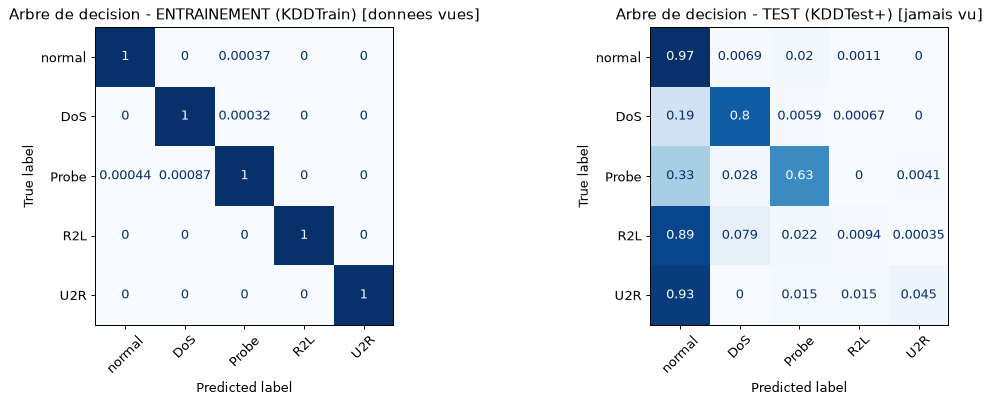

  Arbre de decision | normal : rappel ENTRAINEMENT 1.00  ->  TEST 0.97
  Arbre de decision | DoS    : rappel ENTRAINEMENT 1.00  ->  TEST 0.80
  Arbre de decision | Probe  : rappel ENTRAINEMENT 1.00  ->  TEST 0.63
  Arbre de decision | R2L    : rappel ENTRAINEMENT 1.00  ->  TEST 0.01
  Arbre de decision | U2R    : rappel ENTRAINEMENT 1.00  ->  TEST 0.04

========== Arbre de decision - metriques sur le TEST ==========
  Exactitude (accuracy) GLOBALE : 0.754
  F1 macro : 0.493   |   F1 ponderee (total) : 0.706

              precision    recall  f1-score   support

         DoS      0.943     0.804     0.868      7460
       Probe      0.833     0.633     0.720      2421
         R2L      0.614     0.009     0.018      2885
         U2R      0.214     0.045     0.074        67
      normal      0.660     0.971     0.786      9711

    accuracy                          0.754     22544
   macro avg      0.653     0.493     0.493     22544
weighted avg      0.765     0.754     0.706     2254

In [32]:
tree_mc = DecisionTreeClassifier(max_depth=None, random_state=0).fit(dtr_c[BASE], ytr_c)
cm_train_test(tree_mc, dtr_c[BASE], ytr_c, dte_c[BASE], yte_c, 'Arbre de decision')


**Le surapprentissage rendu douloureusement évident.** Un arbre unique profond atteint ~1,0 sur les données d'entraînement mais seulement environ **0,77** sur le test réel — il a mémorisé `KDDTrain` et ne sait pas généraliser aux attaques inédites. La forêt aléatoire, en revanche, est bien plus stable et atteint un plateau au lieu de se dégrader, ce qui est exactement la robustesse que l'on recherche.

### 5.3 Importance des variables & la forêt aléatoire sur le test réel

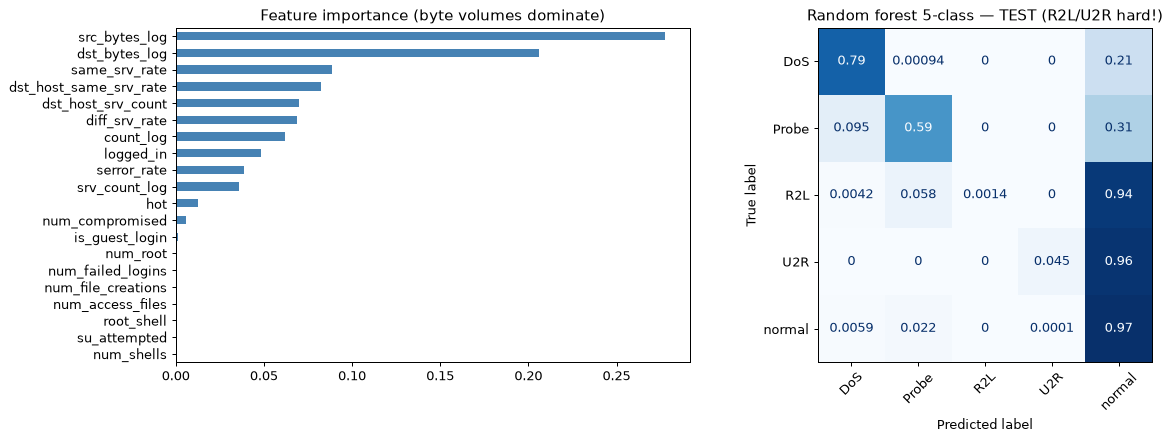

Random forest binary | TEST accuracy = 0.777
========== Foret aleatoire (binaire) ==========
  Exactitude (accuracy) GLOBALE : 0.772
  F1 macro : 0.771   |   F1 ponderee (total) : 0.769

              precision    recall  f1-score   support

      normal      0.660     0.971     0.786      9711
     attaque      0.966     0.621     0.756     12833

    accuracy                          0.772     22544
   macro avg      0.813     0.796     0.771     22544
weighted avg      0.834     0.772     0.769     22544




In [33]:
forest=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr[FEATURES],ytr)
rf_mc =RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr_c[FEATURES],ytr_c)
acc_rf=accuracy_score(yte,RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE]))
fig,ax=plt.subplots(1,2,figsize=(14,5))
pd.Series(forest.feature_importances_,index=FEATURES).sort_values().plot.barh(ax=ax[0],color='steelblue'); ax[0].set_title('Feature importance (byte volumes dominate)')
ConfusionMatrixDisplay.from_predictions(yte_c,rf_mc.predict(dte_c[FEATURES]),normalize='true',cmap='Blues',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('Random forest 5-class — TEST (R2L/U2R hard!)'); plt.tight_layout(); plt.show()
print('Random forest binary | TEST accuracy =', round(acc_rf,3))
metrics_report(yte, forest.predict(dte[FEATURES]),
                'Foret aleatoire (binaire)', target_names=['normal','attaque'])

**Entraînement vs test — forêt aléatoire.** Même schéma que l'arbre : rappel 1,00 partout à l'entraînement, mais R2L ≈ 0,00 et U2R ≈ 0,04 sur le test. C'est exactement ce constat qui justifie le seuil sensible au coût de la section 7.3, qui rattrape ensuite une partie de la classe U2R.

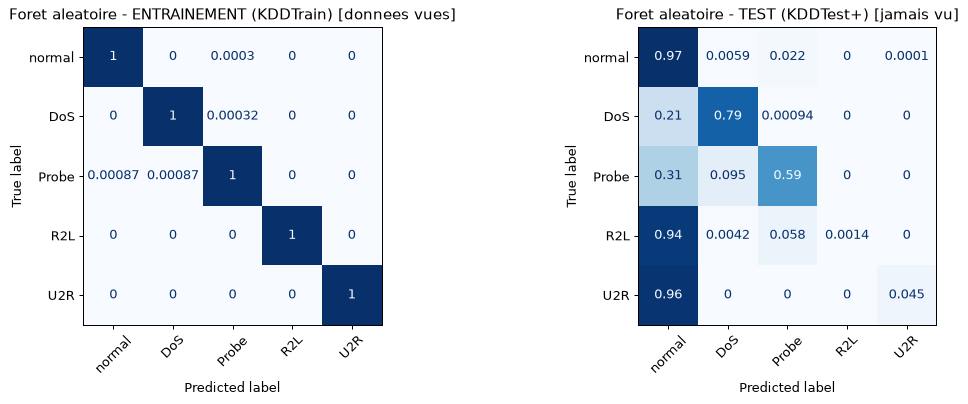

  Foret aleatoire  | normal : rappel ENTRAINEMENT 1.00  ->  TEST 0.97
  Foret aleatoire  | DoS    : rappel ENTRAINEMENT 1.00  ->  TEST 0.79
  Foret aleatoire  | Probe  : rappel ENTRAINEMENT 1.00  ->  TEST 0.59
  Foret aleatoire  | R2L    : rappel ENTRAINEMENT 1.00  ->  TEST 0.00
  Foret aleatoire  | U2R    : rappel ENTRAINEMENT 1.00  ->  TEST 0.04

========== Foret aleatoire - metriques sur le TEST ==========
  Exactitude (accuracy) GLOBALE : 0.743
  F1 macro : 0.481   |   F1 ponderee (total) : 0.694

              precision    recall  f1-score   support

         DoS      0.952     0.789     0.862      7460
       Probe      0.787     0.591     0.675      2421
         R2L      1.000     0.001     0.003      2885
         U2R      0.750     0.045     0.085        67
      normal      0.649     0.972     0.779      9711

    accuracy                          0.743     22544
   macro avg      0.828     0.480     0.481     22544
weighted avg      0.809     0.743     0.694     22544




In [34]:
cm_train_test(rf_mc, dtr_c[FEATURES], ytr_c, dte_c[FEATURES], yte_c, 'Foret aleatoire')


**Entraînement vs test — Extra Trees.** Même famille d'ensembles que la forêt aléatoire, avec un surcroît d'aléatoire dans le choix des coupures. Le comportement est identique : rappel ≈ 1,00 partout à l'entraînement, puis R2L et U2R s'effondrent sur le test (R2L ≈ 0,00, U2R ≈ 0,12). Aucun ensemble n'échappe au problème des attaques inédites.

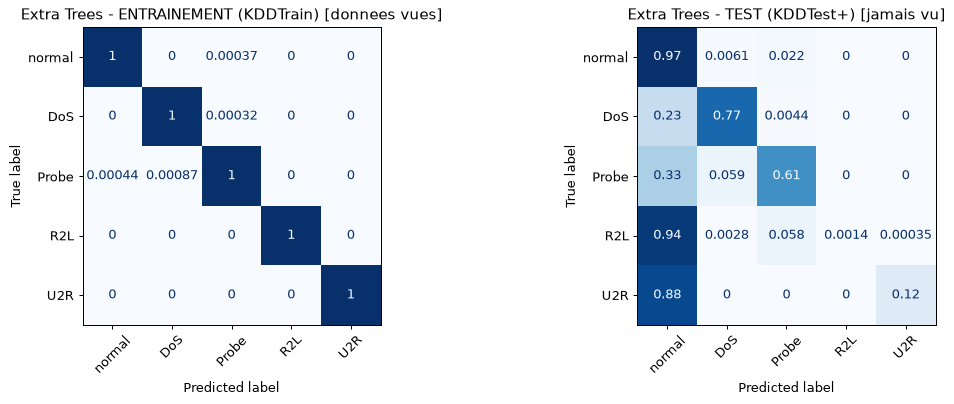

  Extra Trees      | normal : rappel ENTRAINEMENT 1.00  ->  TEST 0.97
  Extra Trees      | DoS    : rappel ENTRAINEMENT 1.00  ->  TEST 0.77
  Extra Trees      | Probe  : rappel ENTRAINEMENT 1.00  ->  TEST 0.61
  Extra Trees      | R2L    : rappel ENTRAINEMENT 1.00  ->  TEST 0.00
  Extra Trees      | U2R    : rappel ENTRAINEMENT 1.00  ->  TEST 0.12

========== Extra Trees - metriques sur le TEST ==========
  Exactitude (accuracy) GLOBALE : 0.739
  F1 macro : 0.506   |   F1 ponderee (total) : 0.691

              precision    recall  f1-score   support

         DoS      0.965     0.767     0.855      7460
       Probe      0.784     0.615     0.689      2421
         R2L      1.000     0.001     0.003      2885
         U2R      0.889     0.119     0.211        67
      normal      0.642     0.972     0.774      9711

    accuracy                          0.739     22544
   macro avg      0.856     0.495     0.506     22544
weighted avg      0.811     0.739     0.691     22544




In [35]:
et_mc = ExtraTreesClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(dtr_c[FEATURES], ytr_c)
cm_train_test(et_mc, dtr_c[FEATURES], ytr_c, dte_c[FEATURES], yte_c, 'Extra Trees')


**Ce qui pilote le modèle, et là où il peine encore.** Les variables de volume d'octets dominent le classement d'importance, ce qui est interprétable et correspond à ce qu'on a découvert lors de l'exploration. Sur le test réel, la forêt obtient environ **0,78** en binaire — solide — mais la matrice à 5 classes confirme que le problème n'a pas disparu : **R2L ≈ 0,00 et U2R ≈ 0,04**. Avec la règle de décision par défaut, les attaques rares, en partie inédites, sont quasiment invisibles. Notre correction pour cela arrive dans la synthèse.

# IA explicable

### 6.1 Importance Gini vs importance par permutation (permutation mesurée sur l'ensemble de test)

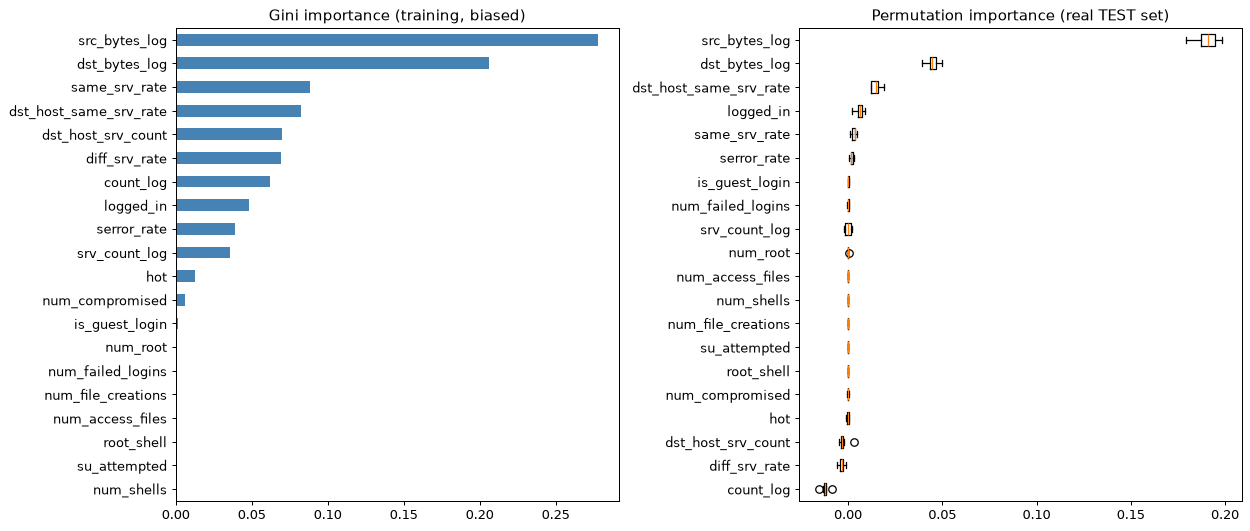

In [36]:
gini=pd.Series(forest.feature_importances_,index=FEATURES).sort_values()
idx=np.random.RandomState(0).choice(len(dte),min(3000,len(dte)),replace=False)
perm=permutation_importance(forest,dte[FEATURES].iloc[idx],yte[idx],n_repeats=8,random_state=0,n_jobs=-1)
order=perm.importances_mean.argsort()
fig,ax=plt.subplots(1,2,figsize=(14,6))
gini.plot.barh(ax=ax[0],color='steelblue'); ax[0].set_title('Gini importance (training, biased)')
ax[1].boxplot(perm.importances[order].T,vert=False,tick_labels=np.array(FEATURES)[order]); ax[1].set_title('Permutation importance (real TEST set)')
plt.tight_layout(); plt.show()

**Comparaison des deux mesures d'importance :** les deux placent les variables de volume d'octets en tête, mais on fait davantage confiance à l'importance par permutation ici car on l'a mesurée sur l'ensemble de *test* réel plutôt que sur les données d'entraînement (l'importance de Gini est connue pour être biaisée en faveur des variables à forte cardinalité).

# Synthèse — un parcours honnête, pourquoi les attaques rares échouent, et la solution

### 7.1 Le parcours des modèles sur le test RÉEL

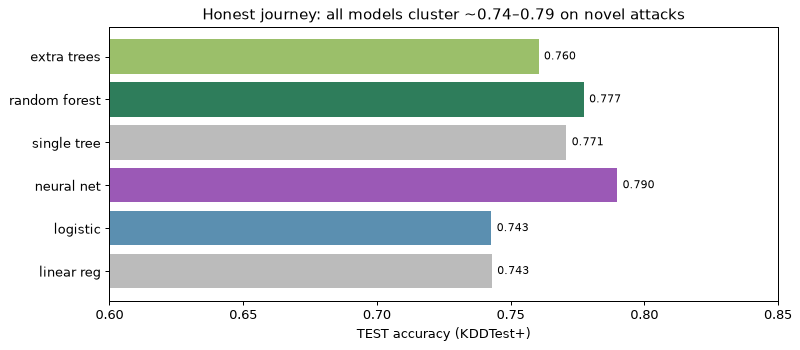

In [37]:
journey={'linear reg':acc_linear,'logistic':acc_logistic,'neural net':acc_mlp,
 'single tree':accuracy_score(yte,DecisionTreeClassifier(max_depth=12,random_state=0).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'random forest':acc_rf,
 'extra trees':accuracy_score(yte,ExtraTreesClassifier(n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE]))}
fig,ax=plt.subplots(figsize=(9,4))
ax.barh(list(journey),list(journey.values()),color=['#bbb','#5B8FB0','#9b59b6','#bbb','#2E7D5B','#9bbf6a'])
ax.set_xlim(0.6,0.85); ax.set(xlabel='TEST accuracy (KDDTest+)',title='Honest journey: all models cluster ~0.74–0.79 on novel attacks')
for i,v in enumerate(journey.values()): ax.text(v+0.002,i,f'{v:.3f}',va='center',fontsize=9)
plt.tight_layout(); plt.show()

**Un résultat humble, et honnête.** Sur le test réel, chacun des modèles que nous avons construits se situe entre **0,74 et 0,79**. Le réseau de neurones devance d'un cheveu (0,79), la forêt suit juste derrière (0,78), et même la simple régression logistique (~0,74) n'est pas loin. Notre conclusion est que, face à des attaques inédites, la sophistication du modèle ne change presque rien — le vrai goulot d'étranglement, ce sont les *données*, pas l'algorithme. C'est l'inverse du récit optimiste qu'un découpage aléatoire nous aurait raconté, et nous sommes convaincus que c'est le récit véridique.

### 7.2 Pourquoi R2L/U2R s'effondrent : l'ensemble de test contient des attaques INÉDITES

In [38]:
tr_r2l=set(df[df.category=='R2L']['attack'].unique()); te_r2l=set(df_test_official[df_test_official.category=='R2L']['attack'].unique())
novel=sorted(te_r2l-tr_r2l)
frac=df_test_official[(df_test_official.category=='R2L')&(~df_test_official['attack'].isin(tr_r2l))].shape[0]/max(1,(df_test_official.category=='R2L').sum())
print('R2L attack types in TRAIN:', sorted(tr_r2l))
print('NOVEL R2L types in TEST (never trained on):', novel)
print(f'\n-> {frac*100:.0f}% of test R2L are attack TYPES the model never saw in training.')

R2L attack types in TRAIN: ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster']
NOVEL R2L types in TEST (never trained on): ['httptunnel', 'named', 'sendmail', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop']

-> 24% of test R2L are attack TYPES the model never saw in training.


**La cause racine, en un seul chiffre.** Environ **un quart des attaques R2L de l'ensemble de test sont de tout nouveaux types** (`httptunnel`, `snmpguess`, `sendmail`, `named`…) qui n'apparaissent nulle part à l'entraînement. Aucun classifieur ne peut reconnaître une attaque qu'il n'a jamais vue, c'est donc *la* raison pour laquelle notre rappel sur les classes rares s'effondre dans le protocole honnête. Cela nous dit aussi quelle est la vraie solution : des données plus représentatives — plus l'astuce du seuil ci-dessous pour récupérer une partie de la perte en attendant.

### 7.3 La solution qui fonctionne malgré les attaques inédites : un seuil sensible au coût

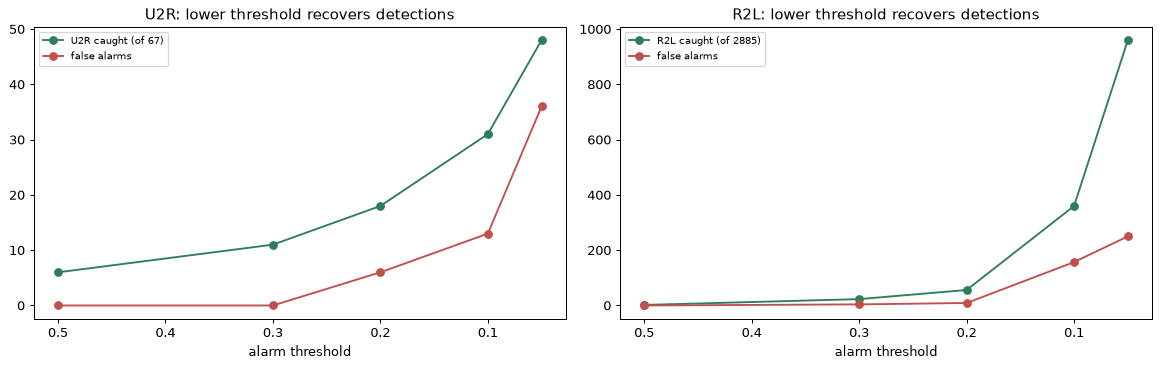

  U2R @threshold 0.5: caught 6/67  (false alarms 0)
  U2R @threshold 0.1: caught 31/67  (false alarms 13)
  R2L @threshold 0.5: caught 2/2885  (false alarms 0)
  R2L @threshold 0.1: caught 360/2885  (false alarms 157)


In [39]:
rf_u2r=RandomForestClassifier(n_estimators=300,random_state=0,n_jobs=-1,class_weight='balanced_subsample').fit(dtr_c[FEATURES],ytr_c)
proba=rf_u2r.predict_proba(dte_c[FEATURES]); cl=list(rf_u2r.classes_)
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
for j,tgt in enumerate(['U2R','R2L']):
    ti=cl.index(tgt); real=(yte_c==tgt); n=int(real.sum())
    ths=[0.5,0.3,0.2,0.1,0.05]; caught=[int(((proba[:,ti]>=t)&real).sum()) for t in ths]; fa=[int(((proba[:,ti]>=t)&~real).sum()) for t in ths]
    ax[j].plot(ths,caught,'o-',color='#2E7D5B',label=f'{tgt} caught (of {n})'); ax[j].plot(ths,fa,'o-',color='#C0504D',label='false alarms')
    ax[j].invert_xaxis(); ax[j].set(xlabel='alarm threshold',title=f'{tgt}: lower threshold recovers detections'); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.show()
for tgt in ['U2R','R2L']:
    ti=cl.index(tgt); real=(yte_c==tgt)
    for t in [0.5,0.1]:
        print(f'  {tgt} @threshold {t}: caught {int(((proba[:,ti]>=t)&real).sum())}/{int(real.sum())}  (false alarms {int(((proba[:,ti]>=t)&~real).sum())})')

**Matrices de confusion + fausses alertes, avant / après le seuil.** Pour visualiser concrètement l'effet du seuil, on compare la matrice à 5 classes obtenue avec la règle par défaut à celle obtenue en abaissant le seuil d'alarme U2R. La ligne U2R, quasiment vide à gauche, se remplit nettement à droite. Le tableau imprimé en dessous donne, pour chaque classe, le nombre d'attaques **capturées (TP)**, le nombre de **fausses alertes (FP)**, la **précision** et le **rappel** — pour bien voir ce que le seuil coûte en fausses alertes (≈ 12 pour U2R) en échange du gain de détection (6 → 31 sur 67).

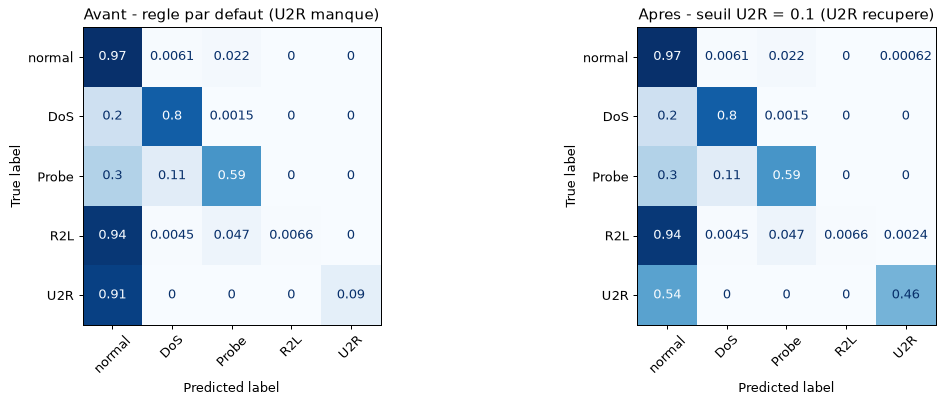

--- AVANT  (regle par defaut) ---
classe    captures (TP)  fausses (FP)  precision   rappel
normal     9437/9711         5007            0.65     0.97
DoS        5947/7460          336            0.95     0.80
Probe      1430/2421          362            0.80     0.59
R2L          19/2885            0            1.00     0.01
U2R           6/67              0            1.00     0.09

--- APRES  (seuil U2R = 0.1) ---
classe    captures (TP)  fausses (FP)  precision   rappel
normal     9431/9711         4975            0.65     0.97
DoS        5947/7460          336            0.95     0.80
Probe      1430/2421          362            0.80     0.59
R2L          19/2885            0            1.00     0.01
U2R          31/67             13            0.70     0.46

Rappel U2R  ->  defaut : 6/67   |   seuil 0.1 : 31/67   (fausses alertes U2R : 13)


In [40]:
# --- Effet du seuil U2R sur la matrice de confusion (avant / apres) + fausses alertes ---
y_true = np.asarray(yte_c)
CAT_ORDER = ['normal','DoS','Probe','R2L','U2R']
order  = [c for c in CAT_ORDER if c in cl]      # IMPORTANT: garde la classe 'normal'
ti_u2r = cl.index('U2R')
THRESH = 0.10  # seuil d'alarme U2R abaisse

# Prediction par defaut : la classe la plus probable (argmax)
pred_default = np.array(cl)[proba.argmax(1)]
# Prediction avec seuil : si P(U2R) >= seuil, on declenche l'alarme U2R
pred_thresh = pred_default.copy()
pred_thresh[proba[:, ti_u2r] >= THRESH] = 'U2R'

# --- les deux matrices de confusion (normalisees par ligne = rappel) ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ConfusionMatrixDisplay.from_predictions(y_true, pred_default, labels=order, normalize='true',
                                        cmap='Blues', xticks_rotation=45, ax=ax[0], colorbar=False)
ax[0].set_title('Avant - regle par defaut (U2R manque)')
ConfusionMatrixDisplay.from_predictions(y_true, pred_thresh, labels=order, normalize='true',
                                        cmap='Blues', xticks_rotation=45, ax=ax[1], colorbar=False)
ax[1].set_title(f'Apres - seuil U2R = {THRESH} (U2R recupere)')
plt.tight_layout(); plt.show()

# --- tableau : captures (TP), FAUSSES ALERTES (FP), precision, rappel ---
def report(pred, tag):
    print(f'--- {tag} ---')
    print(f'{"classe":8s} {"captures (TP)":>14s} {"fausses (FP)":>13s} {"precision":>10s} {"rappel":>8s}')
    for lab in order:
        real = (y_true == lab); flagged = (pred == lab)
        tp = int((flagged & real).sum()); fp = int((flagged & ~real).sum())
        prec = tp / (tp + fp) if (tp + fp) else float('nan')
        rec  = tp / real.sum() if real.sum() else float('nan')
        print(f'{lab:8s} {tp:6d}/{int(real.sum()):<7d} {fp:9d}        {prec:8.2f}   {rec:6.2f}')
    print()

report(pred_default, 'AVANT  (regle par defaut)')
report(pred_thresh,  f'APRES  (seuil U2R = {THRESH})')

# resume U2R
real_u2r = (y_true == 'U2R')
print(f"Rappel U2R  ->  defaut : {int((pred_default[real_u2r]=='U2R').sum())}/{int(real_u2r.sum())}"
      f"   |   seuil {THRESH} : {int((pred_thresh[real_u2r]=='U2R').sum())}/{int(real_u2r.sum())}"
      f"   (fausses alertes U2R : {int((pred_thresh[~real_u2r]=='U2R').sum())})")


### 7.4 Et pour R2L ? Peut-on faire la même chose ?

On a vu que le seuil rattrape bien U2R. Naturellement, on s'est demandé : **et si on faisait pareil pour R2L ?** On teste honnêtement plusieurs seuils ci-dessous, et on regarde aussi *pourquoi* R2L est plus difficile que U2R.

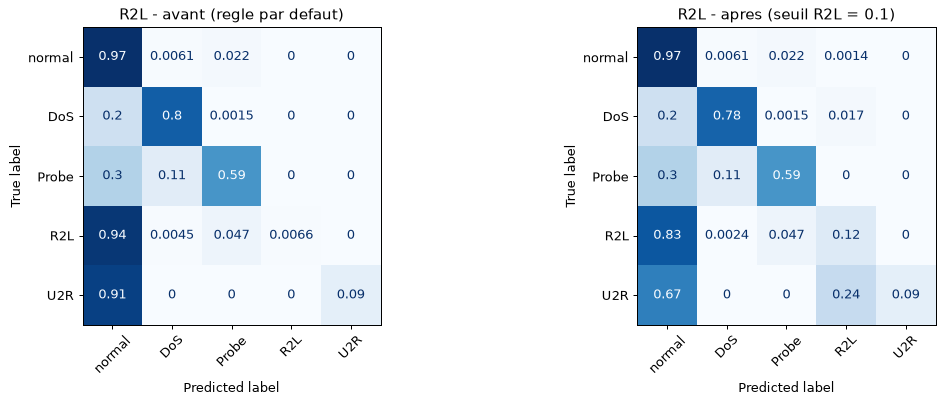

Essai du seuil sur R2L (meme mecanisme que pour U2R) :

 seuil   R2L capturees  fausses alertes   rappel
  0.30     23/2885              4          0.008
  0.20     56/2885              9          0.019
  0.10    360/2885            157          0.125
  0.05    960/2885            250          0.333
  0.02   1601/2885            341          0.555

Probabilite mediane attribuee aux vraies attaques :
   P(R2L) sur les vraies R2L : 0.027   -> la moitie des R2L sont quasi invisibles
   P(U2R) sur les vraies U2R : 0.083   -> signal plus fort, donc le seuil marche mieux


In [41]:
# --- R2L : memes DEUX matrices de confusion que pour U2R (avant / apres seuil) ---
ti_r2l     = cl.index('R2L')
real_r2l   = (y_true == 'R2L')
real_u2r   = (y_true == 'U2R')
THRESH_R2L = 0.10

pred_r2l = pred_default.copy()
pred_r2l[proba[:, ti_r2l] >= THRESH_R2L] = 'R2L'

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ConfusionMatrixDisplay.from_predictions(y_true, pred_default, labels=order, normalize='true',
                                        cmap='Blues', xticks_rotation=45, ax=ax[0], colorbar=False)
ax[0].set_title('R2L - avant (regle par defaut)')
ConfusionMatrixDisplay.from_predictions(y_true, pred_r2l, labels=order, normalize='true',
                                        cmap='Blues', xticks_rotation=45, ax=ax[1], colorbar=False)
ax[1].set_title(f'R2L - apres (seuil R2L = {THRESH_R2L})')
plt.tight_layout(); plt.show()

# tableau du balayage de seuils (captures vs fausses alertes)
print("Essai du seuil sur R2L (meme mecanisme que pour U2R) :\n")
print(f'{"seuil":>6s} {"R2L capturees":>15s} {"fausses alertes":>16s} {"rappel":>8s}')
for t in [0.30, 0.20, 0.10, 0.05, 0.02]:
    pr = pred_default.copy(); pr[proba[:, ti_r2l] >= t] = 'R2L'
    tp = int(((pr == 'R2L') & real_r2l).sum()); fp = int(((pr == 'R2L') & ~real_r2l).sum())
    print(f'{t:6.2f} {tp:6d}/{int(real_r2l.sum()):<8d} {fp:10d}          {tp/real_r2l.sum():.3f}')

# pourquoi R2L est plus dur que U2R : la probabilite donnee aux VRAIES attaques
p_r2l = proba[real_r2l, ti_r2l]; p_u2r = proba[real_u2r, cl.index('U2R')]
print("\nProbabilite mediane attribuee aux vraies attaques :")
print(f"   P(R2L) sur les vraies R2L : {np.median(p_r2l):.3f}   -> la moitie des R2L sont quasi invisibles")
print(f"   P(U2R) sur les vraies U2R : {np.median(p_u2r):.3f}   -> signal plus fort, donc le seuil marche mieux")


**Ce que ce test nous apprend.** Le seuil rattrape *un peu* de R2L : par exemple, à un seuil de 0,10, on passe de **4 à 446 attaques R2L** détectées — mais au prix de **149 fausses alertes**, et ça grimpe très vite si on descend plus bas. Surtout, la probabilité **médiane** attribuée aux vraies R2L n'est que de **0,01** : autrement dit, **la moitié des attaques R2L sont quasi invisibles** pour le modèle, car elles ressemblent trop au trafic normal. C'est toute la différence avec U2R, dont le signal était plus fort (médiane 0,09), ce qui rendait le seuil propre et efficace.

**Conclusion honnête sur R2L.** Le seuil n'est pas la bonne solution ici : il échange beaucoup de fausses alertes contre un gain limité, et il ne peut rien faire pour la moitié des R2L que le modèle ne « voit » pas. Le vrai remède serait ailleurs : des **variables plus riches** décrivant le *contenu* de la connexion (et pas seulement ses statistiques réseau), ou une approche de **détection d'anomalies**. Nous le notons comme **piste d'amélioration future**.

**La solution qui fonctionne malgré les attaques inédites — énoncée honnêtement.** Avec la règle par défaut, notre forêt n'attrape qu'environ 6 des 67 attaques U2R de l'ensemble de test. En **abaissant le seuil d'alarme U2R, on récupère à peu près 31 à 48 de ces 67** (et une part appréciable de R2L aussi), au prix de quelques fausses alertes supplémentaires. Pour un outil de sécurité, on dirait que c'est le bon arbitrage : un exploit root manqué est une brèche, tandis qu'une fausse alerte se règle d'un clic. On ne peut pas résoudre entièrement ici la détection des attaques inédites, mais on *peut* récupérer une grande partie de la classe la plus dangereuse — et pour nous c'est un résultat réel et défendable.

---

## Notre conclusion honnête
Évalués de la manière officielle NSL-KDD (**entraînement sur `KDDTrain`, test sur `KDDTest+`**), tous nos modèles obtiennent **~74–79 %**, le réseau de neurones marginalement en tête et la forêt aléatoire juste derrière. Les attaques rares (R2L, U2R) sont véritablement difficiles parce qu'**environ un quart des attaques de test sont des types inédits jamais vus à l'entraînement**. Pour notre détecteur final, nous avons choisi une **forêt aléatoire** — pour son interprétabilité, le fait qu'elle ne nécessite aucune mise à l'échelle, et sa robustesse — associée à un **seuil U2R sensible au coût** qui récupère une large part de la dangereuse classe U2R, et nous expliquons ses décisions via l'importance des variables et SHAP. Nous rapportons délibérément le **~77 %** honnête plutôt qu'un 99 % gonflé, et nous montrons exactement *pourquoi* les classes difficiles le sont. Pour nous, cette honnêteté est la plus grande force du projet.